# **Bank Marketing Campaign - Term Deposit Analysis and Prediction**

**Purwadhika Job Connector Data Science (JCDSJKTPM-34) Final Project (Remedial)**

Author: Tengku Arika Hazera

Date: 6 July 2026

## Import Library

In [1]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.4 MB/s eta 0:00:00


In [2]:
# Basic library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Statistical library
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu

# ML library
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, LabelEncoder, OneHotEncoder, OrdinalEncoder, TargetEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, make_scorer, fbeta_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# Imblearn
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, NearMiss
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

# Metrics library
from sklearn.metrics import (classification_report, confusion_matrix,
                            accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, roc_curve,
                            precision_recall_curve, auc, make_scorer, fbeta_score)
# Time
import time

# Model interpretation
import shap

# Model saving
import joblib

In [3]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Load Dataset

In [4]:
df = pd.read_csv('raw_data.csv', sep=';', na_values='unknown')
df = df.rename(columns={'y': 'deposit'})  # renamed target column 'y' to 'deposit'
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposit
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df_processed = df.copy()

## **1. Introduction**

### **1.1 Context**

This project analyzes [marketing campaign data related to term deposits](https://www.kaggle.com/code/volodymyrgavrysh/bank-marketing-campaigns-dataset-analysis) offered by a Portuguese bank to its customers. The campaigns were conducted primarily through direct phone calls, offering customers the opportunity to subscribe a term deposit. The data were collected from [May 2008 to November 2010](https://archive.ics.uci.edu/dataset/222/bank+marketing). The dataset contains information about:

- Bank customer demographics and financial status
- Campaign contact details
- Previous campaign outcomes
- Social and economic context indicators

The objective is to predict whether a customer will subscribe to a term deposit based on these features.

In 2008, a global financial crisis originated in the United States, which disrupted banking systems worldwide, including Portuguese banks. Using the available banking data, this project also analyzes the impact of the financial pre-crisis, during crisis and the post-crisis recovery period on customers' term-deposit subscription behavior.

### **1.2 Business Problem**

Banks invest significant resources in marketing campaigns for term deposits. However, not all customers are equally likely to subscribe. A mass marketing approach without proper targeting may result in:

1. Wasted resources on customers unlikely to subscribe
2. Inefficient allocation of call center time
3. Potential customer fatigue from excessive contact attempts
4. Suboptimal return on investment (ROI) from marketing campaigns

In addition, the data collection period (2008-2010) coincides with the global financial crisis and the economic recovery phase in Portugal. Macroeconomic conditions such as declining interest rates (Euribor), rising unemployment, and decreasing consumer confidence may influence customers' behavior when making financial decisions, including subscribing to term deposits.

As a result, campaign success is influenced not only by individual customer characteristics but also by the prevailing economic conditions at the time of the campaign. Marketing strategies that are effective during normal periods may not be optimal during crisis or recovery phases.

Therefore, the bank needs to understand:
which customers are the most promising targets and how changes in economic conditions affect the probability of term-deposit subscriptions, so that marketing strategies can be dynamically adjusted according to each economic phase to maximize campaign effectiveness and efficiency.

`Key Questions`:

- Which customers are most likely to subscribe to term deposits?
- What factors most influence a customer's decision?
- How do the financial pre-crisis, during crisis and the recovery period affect term-deposit subscription rates?
- How can we optimize targeting strategies while improving the efficiency of the bank's resource allocation?

### **1.3 Objectives**

`Primary objective`: Analyze customers' data features and build a predictive model to identify customers most likely to subscribe to term deposits, enabling the bank to:

- Optimize marketing campaign efficiency
- Improve customer experience by reducing unnecessary contacts
- Increase overall campaign success rate

`Success metrics`:

- Maximize Recall (minimize missed potential subscribers)
- Achieve high ROC-AUC score
- Achieve strong PR-AUC score for imbalanced data

### **1.4 Analytical Approach**

This project is a **supervised classification** problem, which give informations on:

- Target variable: Has the customer subscribed to a term deposit? (yes/no)
- Approach: Classification algorithms
- Challenge: Class imbalance (fewer subscriptions than non-subscriptions)

**Methodology:**

`Data Analysis`
1. Exploratory Data Analysis (EDA) with inferential statistics
2. Temporal trend analysis to understand changes in customer behavior during the pre-crisis, during crisis and recovery periods

`Machine Learning`

3. Feature Engineering and preprocessing pipelines
4. Model benchmarking across multiple algorithms
5. Handling class imbalance using resampling techniques
6. Hyperparameter tuning to optimize the best-performing model
7. Model evaluation using business-relevant metrics
8. Cost-benefit–based evaluation to measure the financial impact of model decisions
7. Model interpretation for actionable insights

### **1.5 Stakeholders**

 Head of Marketing: Use predictions to prioritize customer contacts

### **1.6 Metrics Selection**

The confusion matrix in this case is defined as follows:
- True Positive (TP): Customers predicted to subscribe who actually subscribe
- False Positive (FP): Customers predicted to subscribe but who do not subscribe → resulting in unnecessary operational costs
- False Negative (FN): Customers predicted not to subscribe but who actually subscribe → resulting in lost revenue opportunities
- True Negative (TN): Customers predicted not to subscribe and who indeed do not subscribe

Considering the business context, False Negative errors have a greater financial impact than False Positive errors. Therefore, the model evaluation strategy focuses on maximizing the ability to capture as many potential customers as possible.

`Primary Metrics`:

**RECALL** (Sensitivity)

- Maximizes the number of potential customers successfully identified
- Reduces revenue loss caused by missed subscribers

`Validation Metrics`:

**ROC-AUC** (Receiver Operating Characteristic - Area Under the Curve)

- Distinguish well between potential subscribers and non subscribers



## **2. Comprehensive Exploratory Data Analysis**

### **2.1 Dataset Info and Data Dictionary**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             40858 non-null  object 
 2   marital         41108 non-null  object 
 3   education       39457 non-null  object 
 4   default         32591 non-null  object 
 5   housing         40198 non-null  object 
 6   loan            40198 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

The dataset has 41,188 row data and 21 columns.

**Descriptive data**

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
df.describe(include='object')

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,deposit
count,40858,41108,39457,32591,40198,40198,41188,41188,41188,41188,41188
unique,11,3,7,2,2,2,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


- Admin job, married status, education of university degree dominated the population

In [9]:
df_unique = []

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

for i in df.columns:
    unique_count = df[i].nunique()
    unique_values = df[i].unique()
    data_type = df[i].dtype
    df_unique.append({
        "Column Name": i,
        "Number of Unique": unique_count,
        "Data Type": data_type,
        "Unique Sample": unique_values
    })

df_unique = pd.DataFrame(df_unique)
display(df_unique)

,Column Name,Number of Unique,Data Type,Unique Sample
0,age,78,int64,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 54, 46, 50, 39, 30, 55, 49, 34, 52, 58, 32, 38, 44, 42, 60, 53, 47, 51, 48, 33, 31, 43, 36, 28, 27, 26, 22, 23, 20, 21, 61, 19, 18, 70, 66, 76, 67, 73, 88, 95, 77, 68, 75, 63, 80, 62, 65, 72, 82, 64, 71, 69, 78, 85, 79, 83, 81, 74, 17, 87, 91, 86, 98, 94, 84, 92, 89]"
1,job,11,object,"[housemaid, services, admin., blue-collar, technician, retired, management, unemployed, self-employed, nan, entrepreneur, student]"
2,marital,3,object,"[married, single, divorced, nan]"
3,education,7,object,"[basic.4y, high.school, basic.6y, basic.9y, professional.course, nan, university.degree, illiterate]"
4,default,2,object,"[no, nan, yes]"
5,housing,2,object,"[no, yes, nan]"
6,loan,2,object,"[no, yes, nan]"
7,contact,2,object,"[telephone, cellular]"
8,month,10,object,"[may, jun, jul, aug, oct, nov, dec, mar, apr, sep]"
9,day_of_week,5,object,"[mon, tue, wed, thu, fri]"


#### <u>Columns description


**Naming cleanup**

`Personal data`

1. age (numerical)
2. job: type of job (categorical)
3. marital: marital status (categorical)
4. education (categorical)
5. default: has credit in default or not (categorical)
6. housing: has housing loan or not(categorical)
7. loan: has personal loan or not (categorical)

`Related to last contact with potential customers`

8. contact: contact communication type (categorical)
9. month: last contact month of year (categorical)
10. day of week: last contact day of week (categorical)
11. duration: last contact duration in seconds (numerical)

`Other attributes`

12. campaign: number of contacts performed during this campaign and for this customer (numerical)
13. pdays: number of days that passed by after the customer was last contacted from a previous campaign (999 = not contacted) (numerical)
14. previous: number of contacts performed before this campaign and for this customer (numerical)
15. poutcome: outcome of the previous marketing campaign (categorical)

`Socioeconomic context`

16. emp.var.rate: employment variation rate - quarterly indicator (numerical)
17. cons.price.idx: consumer price index - monthly indicator (numerical)
18. cons.conf.idx: consumer confidence index - monthly indicator (numerical)
19. euribor3m: 3-month interbank lending rate in Europe - daily indicator (percentage)
20. nr.employed: number of employees - quarterly indicator (numerical)

`Target variable`

21. deposit: has the customer subscribed a term deposit? (categorical)

In [10]:
df['job'] = df['job'].replace({'admin.': 'admin'})
df['education'] = df['education'].replace({'university.degree': 'university degree'})
df['education'] = df['education'].replace({'professional.course': 'professional course'})
df['education'] = df['education'].replace({'high.school': 'high school'})
df['education'] = df['education'].replace({'basic.9y': 'basic 9 years'})
df['education'] = df['education'].replace({'basic.4y': 'basic 4 years'})
df['education'] = df['education'].replace({'basic.6y': 'basic 6 years'})

### **2.2 Missing Values and Duplicates Handling**



`Data analysis`

1. Drop duplicates
2. default : Impute misssing value with 'unknown'

`Machine learning`
1. Drop Duplicates
2. job: Impute with simple imputer
3. marital: Impute with simple imputer
4. education: Impute with simple imputer
5. default: Generate default_status_known and **Droping original column** (only 3 'yes' vs 40,000+ 'no' - not informative)
6. housing: **Drop rows** with missing values (dropna)
7. loan: **Drop rows** with missing values (dropna)

In [11]:
dup=df.duplicated().sum()
percent_dup=df.duplicated().sum()/len(df)*100
print(dup, percent_dup)


12 0.02913469942701758


There are 12 row or 0.03% duplicated data in the dataset.

In [12]:
df.drop_duplicates(inplace=True)

#### <u>Missing values percentage

In [13]:
df_null=pd.DataFrame(df.isna().sum()).reset_index().rename(columns={'index':'Column',0:'Count Missing'})
df_null['Missing %']=(round(100*df.isna().sum()/len(df),4)).reset_index(drop=True)
df_null

,Column,Count Missing,Missing %
0,age,0,0.0000
1,job,330,0.8014
2,marital,80,0.1943
3,education,1730,4.2015
4,default,8596,20.8762
5,housing,990,2.4043
6,loan,990,2.4043
7,contact,0,0.0000
8,month,0,0.0000
9,day_of_week,0,0.0000


The highest missing values are from `default` feature by 20.87%.

<Axes: title={'center': 'Missing Values Heatmap'}>

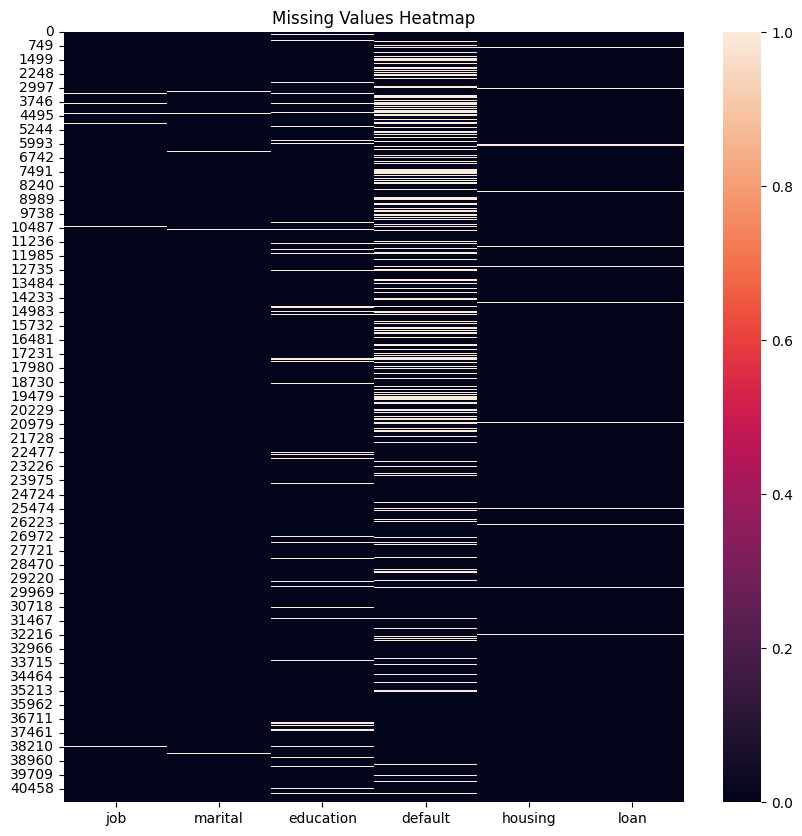

In [14]:
plt.figure(figsize=(10,10))
plt.title('Missing Values Heatmap')
sns.heatmap(df[['job', 'marital', 'education', 'default', 'housing', 'loan']].isna())

These missing values may happen due to some underlying reasons such as:

1. Customers refused to disclose their information to the bank

2. Customers may not take loan in the this bank, therefore the `default` feature has a lot of missing values

3. Telemarketing data and retail banking data are not synchronized

*note: based on the heatmap, `housing` and `loan` may have connection with each other.

### **2.3 Outliers Handling**

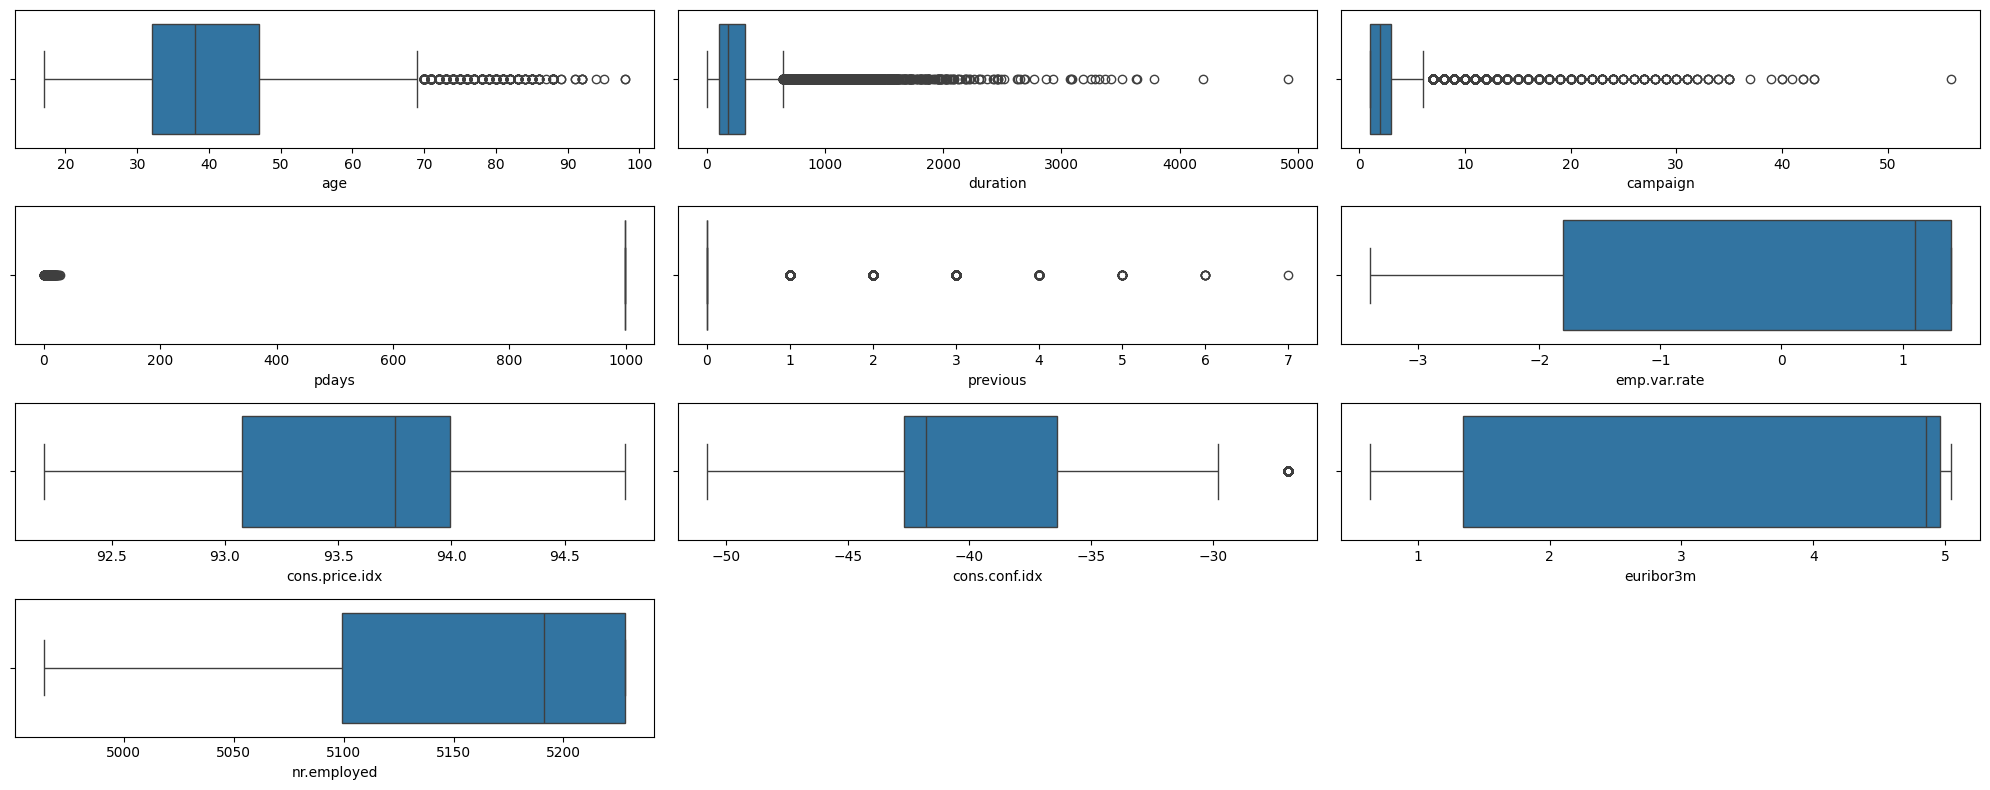

In [15]:
fig, axes = plt.subplots(4, 3, figsize=(20, 8))
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10, ax11, ax12 = axes.flatten()
sns.boxplot(data=df, x='age',ax=ax1)
sns.boxplot(data=df, x='duration',ax=ax2)
sns.boxplot(data=df, x='campaign',ax=ax3)
sns.boxplot(data=df, x='pdays',ax=ax4)
sns.boxplot(data=df, x='previous',ax=ax5)
sns.boxplot(data=df, x='emp.var.rate',ax=ax6)
sns.boxplot(data=df, x='cons.price.idx',ax=ax7)
sns.boxplot(data=df, x='cons.conf.idx',ax=ax8)
sns.boxplot(data=df, x='euribor3m',ax=ax9)
sns.boxplot(data=df, x='nr.employed',ax=ax10)
fig.delaxes(ax11)
fig.delaxes(ax12)
plt.tight_layout()
plt.show()

The outliers present in `age`, `duration`, `campaign`, `pdays`, `previous`, and `cons.conf.idx` features.

In [16]:
(df['duration']>900).value_counts()

,count
duration,
False,39895
True,1281


In [17]:
(df['campaign']>10).value_counts()

,count
campaign,
False,40307
True,869


In [18]:
df = df[(df['campaign'] <= 10) & (df['duration'] <= 900)].reset_index()

`We remove some of the outliers due:`
- Excessive duration call, 30 minutes seems reasonable
- lots of campaigns

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39044 entries, 0 to 39043
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   index           39044 non-null  int64  
 1   age             39044 non-null  int64  
 2   job             38729 non-null  object 
 3   marital         38972 non-null  object 
 4   education       37412 non-null  object 
 5   default         30938 non-null  object 
 6   housing         38101 non-null  object 
 7   loan            38101 non-null  object 
 8   contact         39044 non-null  object 
 9   month           39044 non-null  object 
 10  day_of_week     39044 non-null  object 
 11  duration        39044 non-null  int64  
 12  campaign        39044 non-null  int64  
 13  pdays           39044 non-null  int64  
 14  previous        39044 non-null  int64  
 15  poutcome        39044 non-null  object 
 16  emp.var.rate    39044 non-null  float64
 17  cons.price.idx  39044 non-null 

After the duplicates and outliers removed, the cleaned data is 39,044 rows data from 41,188.

### **2.4 Exploratory Data Analysis (EDA)**

#### 2.4.1 Target imbalance detection (Univariate)

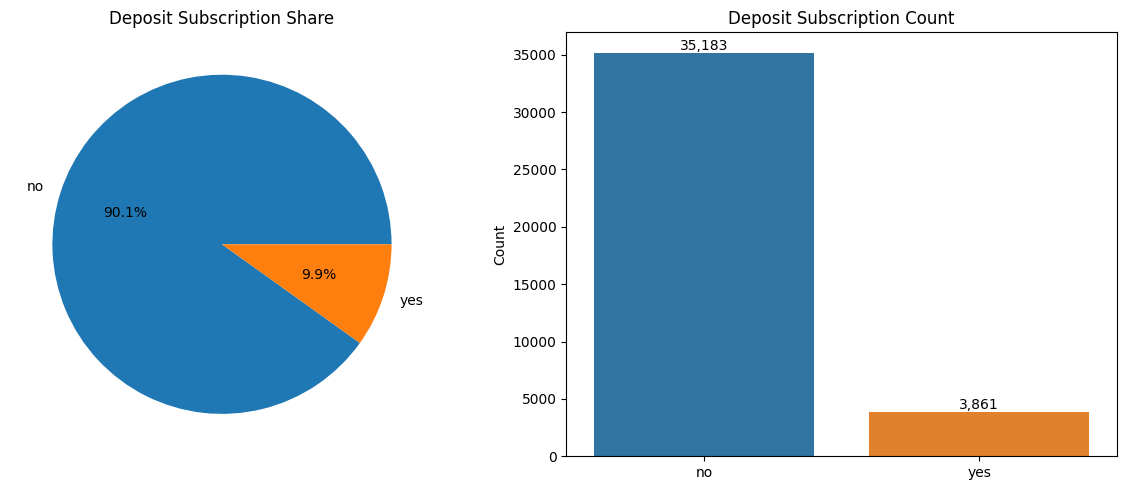

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(df['deposit'].value_counts(), labels=['no', 'yes'], autopct='%1.1f%%',
            colors=['#1F77B4', '#FF7F0E'])
axes[0].set_title('Deposit Subscription Share')

sns.countplot(data=df, x='deposit', order=['no', 'yes'], palette={'no': '#1F77B4','yes': '#FF7F0E'}, ax=axes[1])
axes[1].set_title('Deposit Subscription Count')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                      (p.get_x() + p.get_width() / 2, p.get_height()),
                      ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

We can imply from the chart that the target has a class imbalance with 9.9% of the customers making subscription and 90.1% who do not.

In [21]:
# Helper function
def plot_freq_rate(feature, data=df, order=None, bins=None, bin_labels=None,
                    figsize=(14, 5), rot_freq=45, custom_binner=None):

    plot_data = data.copy()

    if custom_binner is not None:
        plot_data[feature] = plot_data[feature].apply(custom_binner)
    elif bins is not None:
        plot_data[feature] = pd.cut(plot_data[feature], bins=bins, labels=bin_labels, right=False)

    if order is not None:
        plot_data[feature] = pd.Categorical(plot_data[feature], categories=order, ordered=True)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Left: Frequency (vertical bar chart, count on y-axis)
    sns.countplot(data=plot_data, x=feature, order=order, color='#1F77B4', ax=axes[0])
    axes[0].set_title(f'{feature} — Frequency')
    axes[0].set_ylabel('Count')
    axes[0].set_xlabel(feature)
    axes[0].tick_params(axis='x', labelrotation=rot_freq)

    # Right: Subscription rate (%) — horizontal bar chart
    rate = (
        plot_data.groupby(feature, observed=True)['deposit']
        .apply(lambda x: (x == 'yes').mean() * 100)
        .reset_index(name='subscription_rate')
    )
    if order is not None:
        rate[feature] = pd.Categorical(rate[feature], categories=order, ordered=True)
        rate = rate.sort_values(feature)

    sns.barplot(data=rate, y=feature, x='subscription_rate', color='#FF7F0E', ax=axes[1])
    axes[1].set_title(f'{feature} — Subscription Rate (%)')
    axes[1].set_xlabel('Subscription Rate (%)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

#### 2.4.2 Personal data excluding default (Univariate)

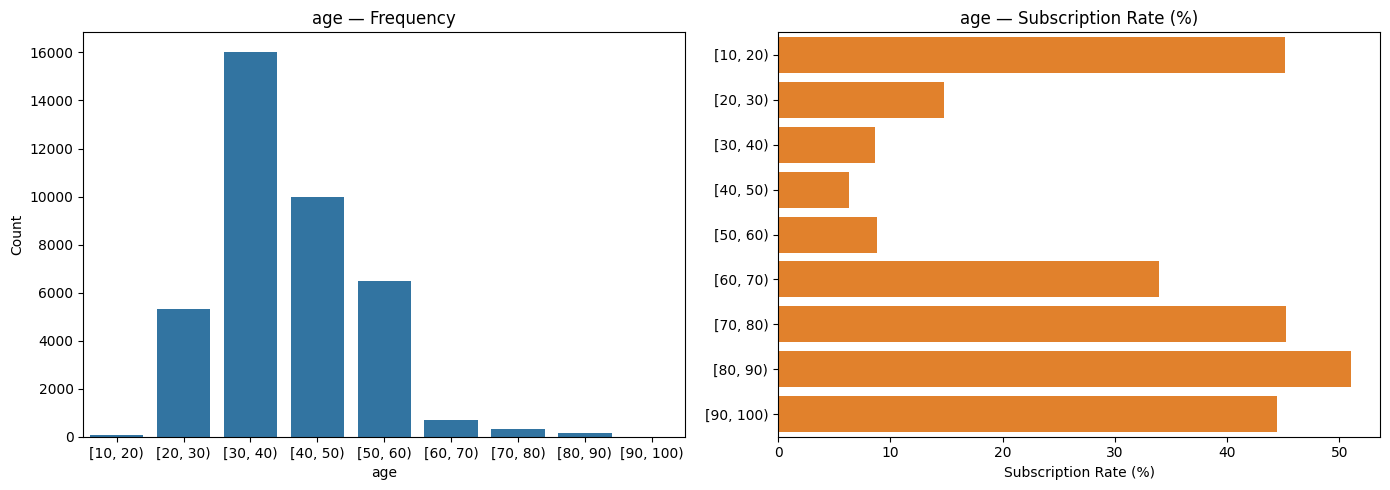

In [22]:
age_bins = list(range(10, 101, 10))
plot_freq_rate('age', bins=age_bins, rot_freq=0)

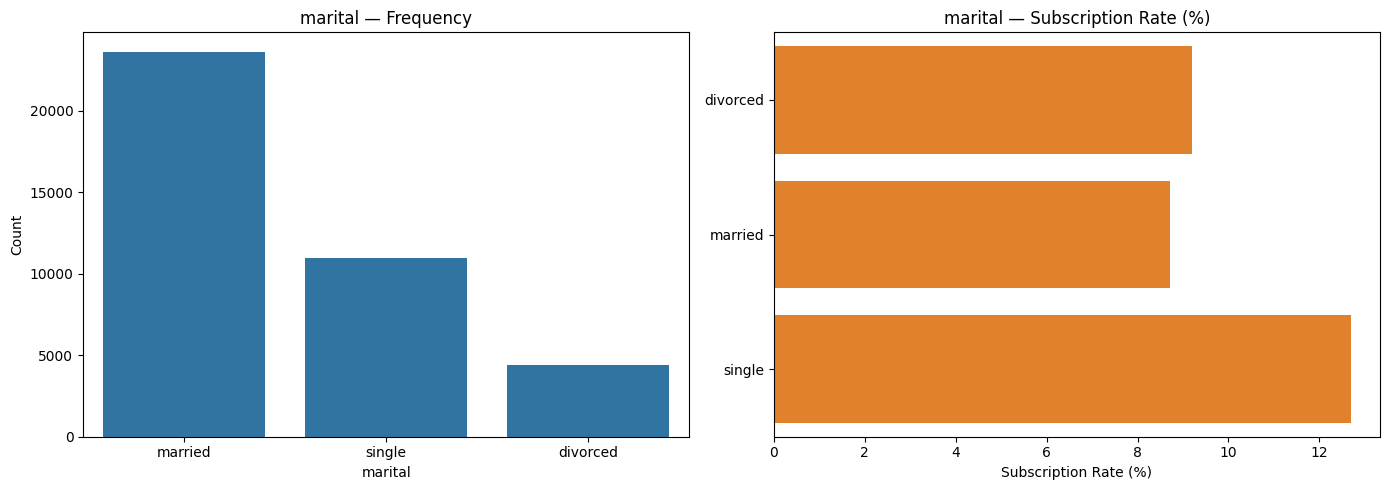

In [23]:
plot_freq_rate('marital', rot_freq=0)

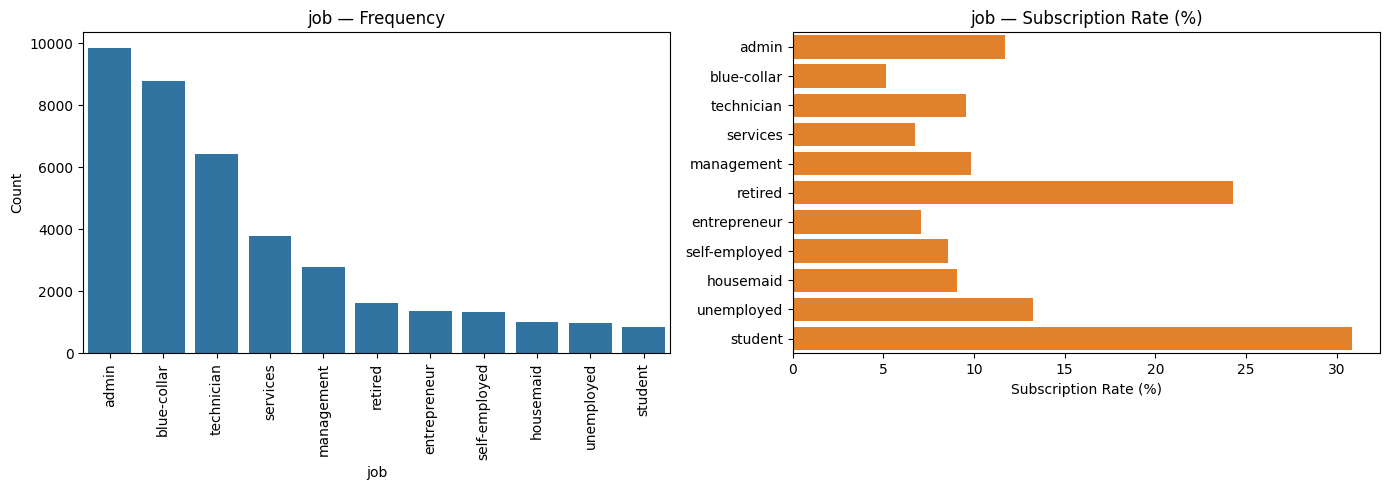

In [24]:
job_order = df['job'].value_counts().index.tolist()
plot_freq_rate('job', order=job_order, rot_freq=90)

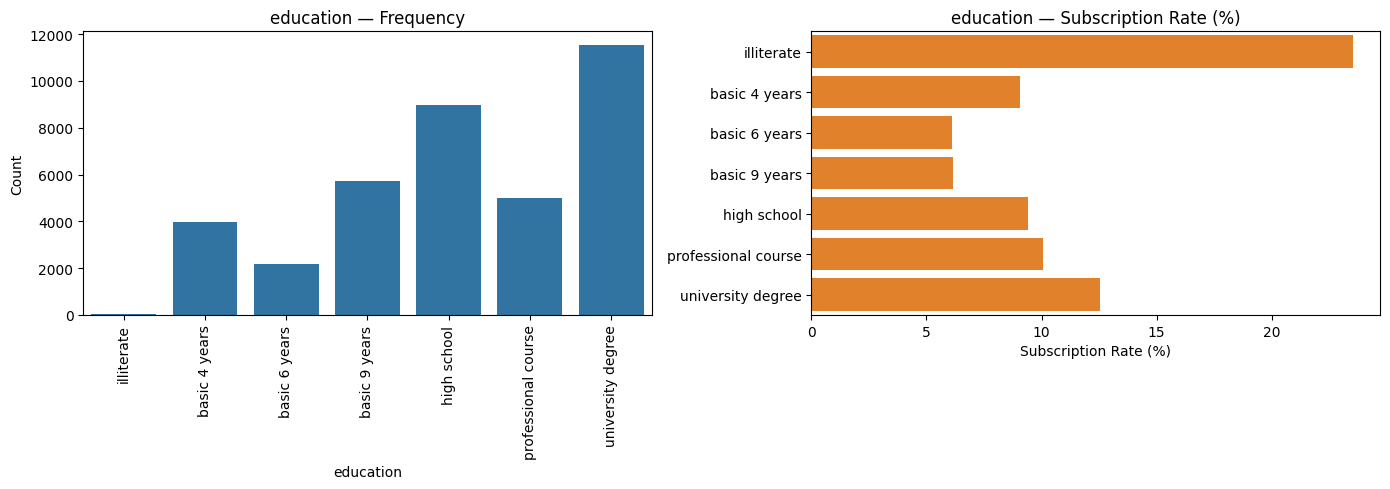

In [25]:
education_order = ['illiterate', 'basic 4 years', 'basic 6 years', 'basic 9 years',
                    'high school', 'professional course', 'university degree']
plot_freq_rate('education', order=education_order, rot_freq=90)

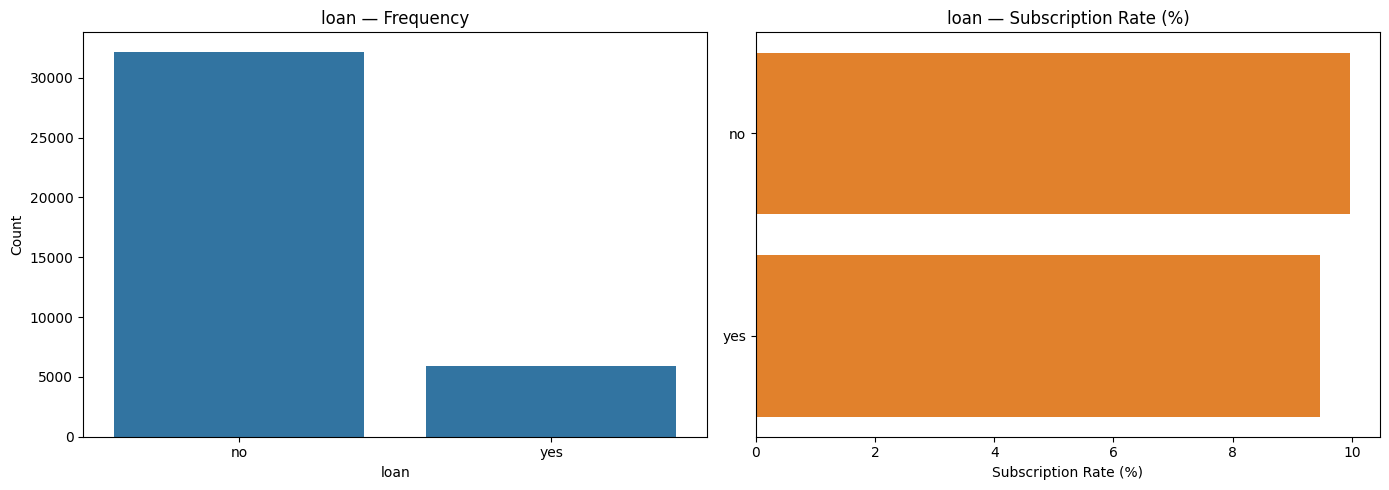

In [26]:
plot_freq_rate('loan', rot_freq=0)

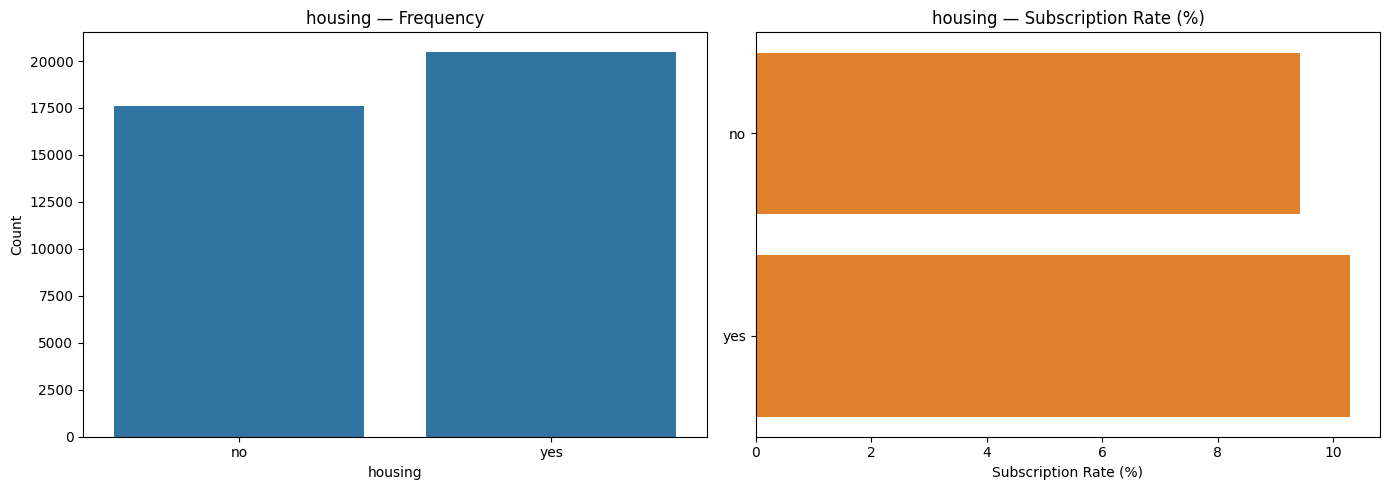

In [27]:
plot_freq_rate('housing', rot_freq=0)

- In all of the plots, "no" class dominates "yes" class
- This shows strong class imbalance

- Age --> Customers in late 20s to early 30s shows higher interest in subscribing deposit
- Marital --> Customers with `marital` status `single` tend to subscribe to deposit more
- Job --> Customers who are `student` and customers who have `retired` tend to subscribe to deposit more
- Education --> Customers who pursued `university degree` tend to subscribe to deposit more
- Loan and Housing have similar distribution proportion within the target, therefore inferential statistic is used to differentiate them

#### 2.4.3 Default

Since the default variable contains more than 20% missing values, these missing entries were recoded as "unknown" to allow for a clearer analysis of the category distribution within the dataset.

In [28]:
df_default=df.copy()
df_default['default'] = df_default['default'].fillna('unknown')

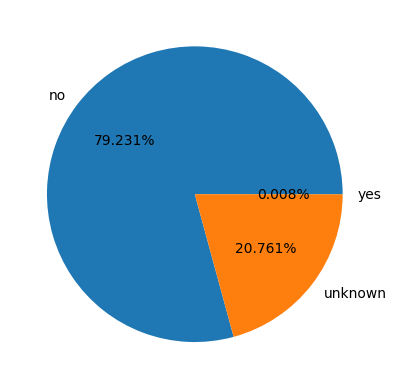

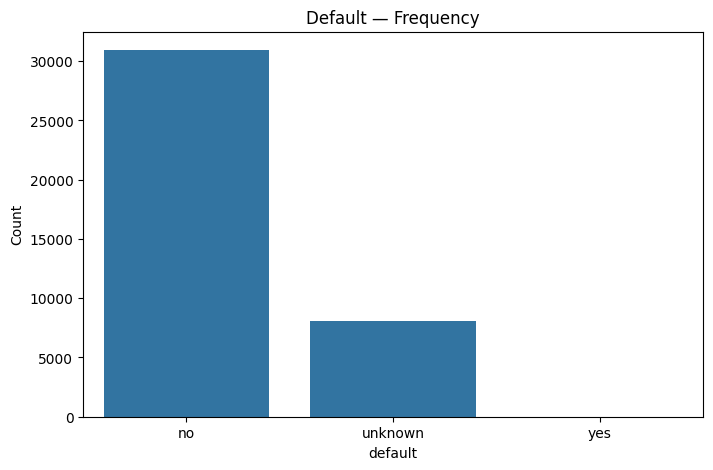

In [29]:
plt.pie(df_default['default'].value_counts(), labels=['no', 'unknown','yes'], autopct='%1.3f%%')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(data=df_default, x='default', order=['no', 'unknown', 'yes'], color='#1F77B4')
plt.title('Default — Frequency')
plt.ylabel('Count')
plt.show()

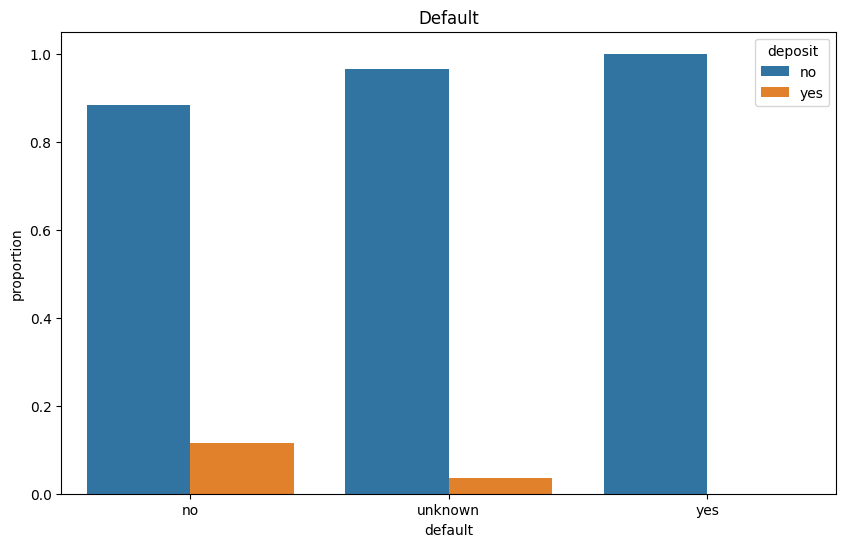

In [30]:
default_reset = (
    df_default
    .groupby('default')['deposit']
    .value_counts(normalize=True)
    .reset_index(name='proportion')
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=default_reset,
    x='default',
    y='proportion',
    hue='deposit',
    palette={'no': '#1F77B4', 'yes': '#FF7F0E'}
)

plt.title("Default")
plt.show()

`default` feature shows strong class imbalance with "no" target class dominating.

In [31]:
df_default['default'].value_counts()

,count
default,
no,30935
unknown,8106
yes,3


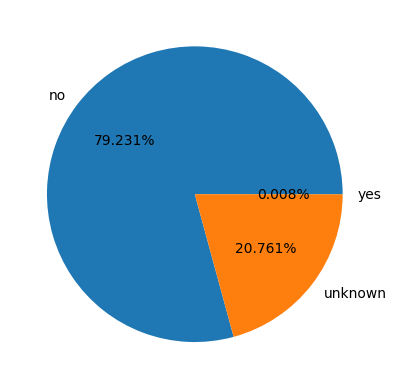

In [32]:
plt.pie(df_default['default'].value_counts(), labels=['no', 'unknown','yes'], autopct='%1.3f%%')
plt.show()

`default` feature shows strong class imbalance, with the 'yes' class being extremely rare, only 3 observations, representing approximately 0.007% of the total dataset

#### 2.4.4 Related to last campaign contact (Univariate)

In [33]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']
df['month'] = pd.Categorical(df['month'],
                                   categories=month_order,
                                   ordered=True)

day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
df['day_of_week'] = pd.Categorical(df['day_of_week'],
                                   categories=day_order,
                                   ordered=True)

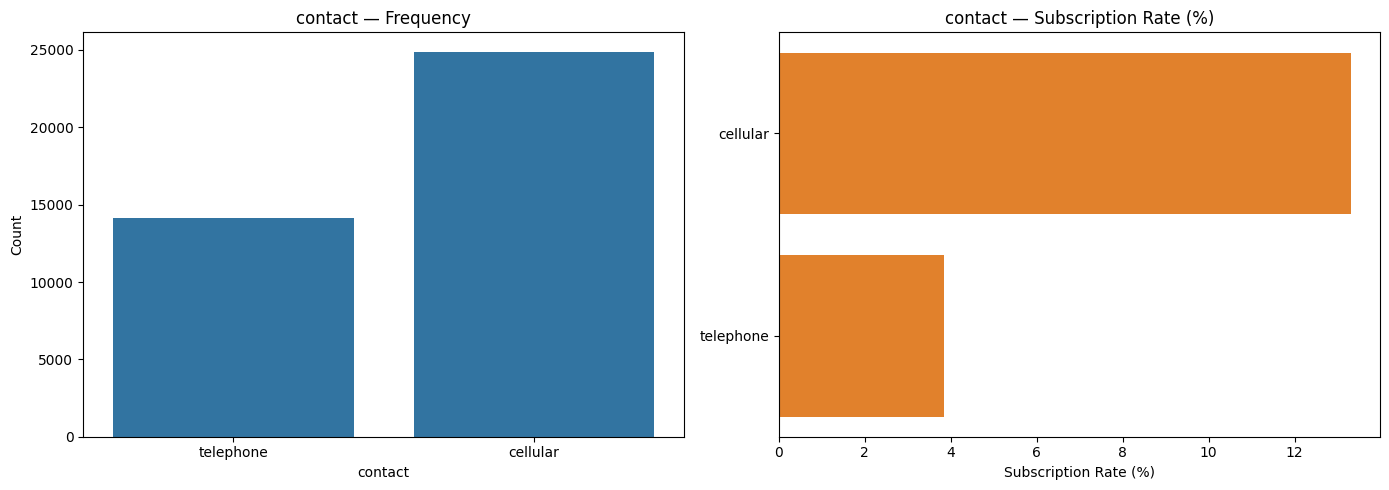

In [34]:
plot_freq_rate('contact', rot_freq=0)

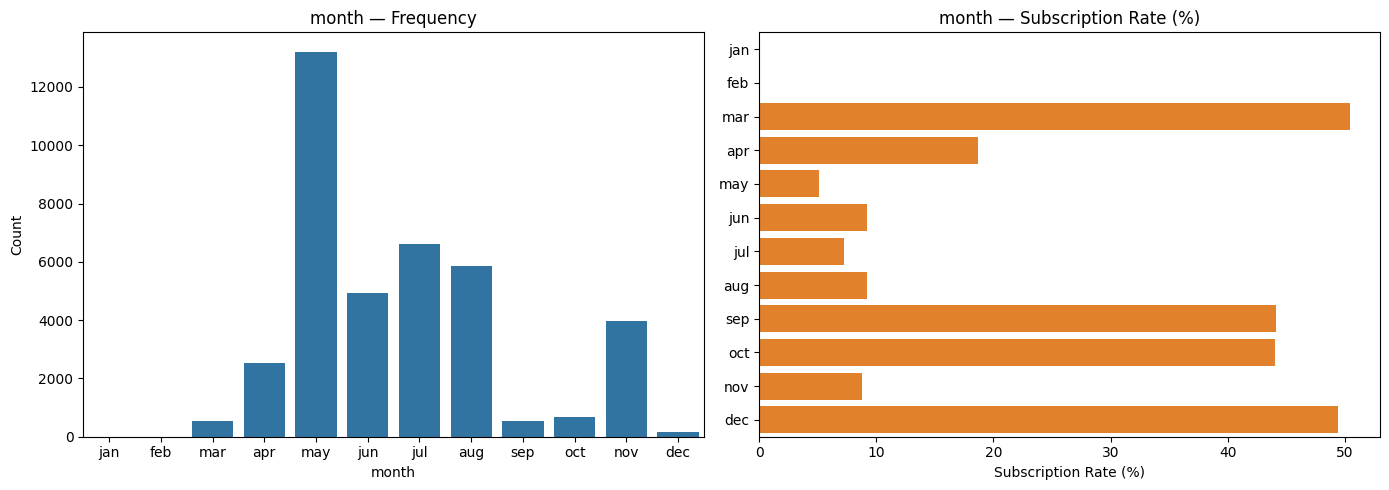

In [35]:
plot_freq_rate('month', order=month_order, rot_freq=0)

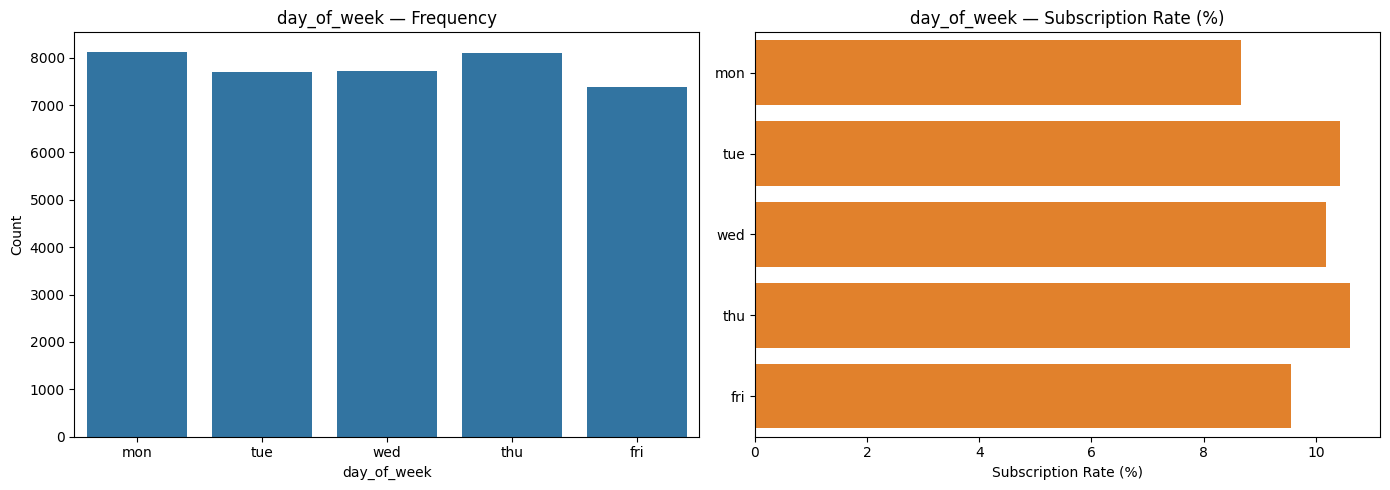

In [36]:
plot_freq_rate('day_of_week', order=day_order, rot_freq=0)

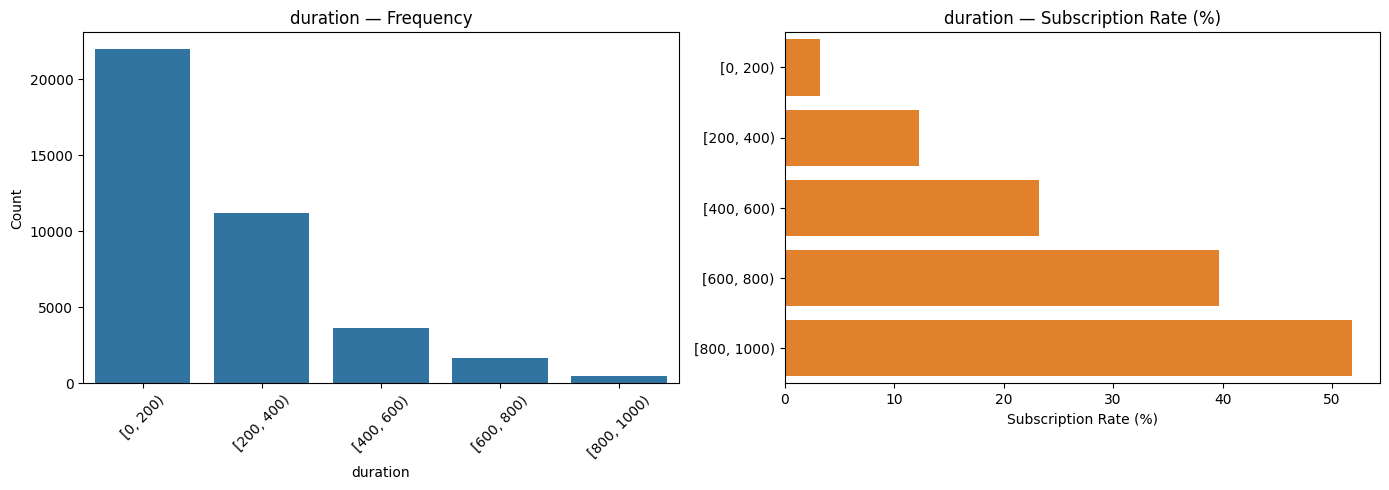

In [37]:
duration_bins = list(range(0, 1001, 200))
plot_freq_rate('duration', bins=duration_bins, rot_freq=45)

The features related to the last campaign contact also show strong class imbalance.

- `contact` --> Customers who are contacted cellular tend to subscribe to deposit more
- `month` --> Customer are contacted in March and December tend to subscribe to deposit more
- `day_of_week` --> all of the days have similar distribution proportion within the target, therefore inferential statistic is used to differentiate them.
- `duration` --> Phone call duration is dominated by shorter calls rather than longer ones

#### 2.4.5 Pdays (Univariate)

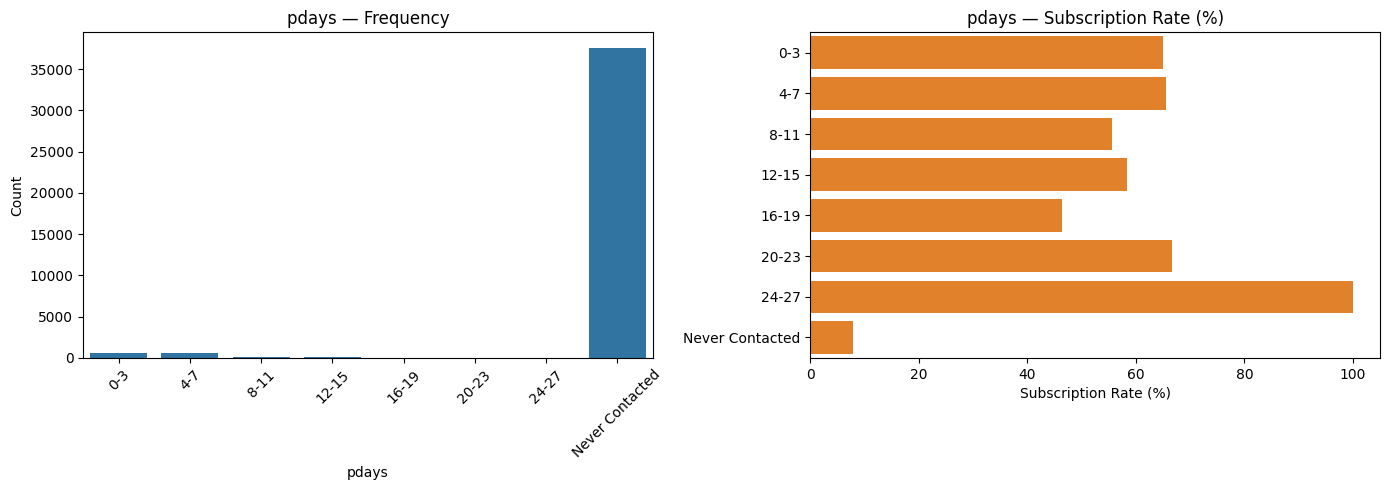

In [38]:
def bin_pdays(x):
    """Bin pdays into 4-day buckets; 999 (never previously contacted) gets its own category."""
    if x == 999:
        return 'Never Contacted'
    bin_start = (x // 4) * 4
    return f'{bin_start}-{bin_start + 3}'

pdays_order = ['0-3', '4-7', '8-11', '12-15', '16-19', '20-23', '24-27', 'Never Contacted']
plot_freq_rate('pdays', custom_binner=bin_pdays, order=pdays_order, rot_freq=45)

- Most customers that have never contacted before (999 pdays) do not subscribe to the deposit product, however customers that have contacted recently (within the first few days) are more likely to subscribe.

#### 2.4.6 Other attributes (Univariate)

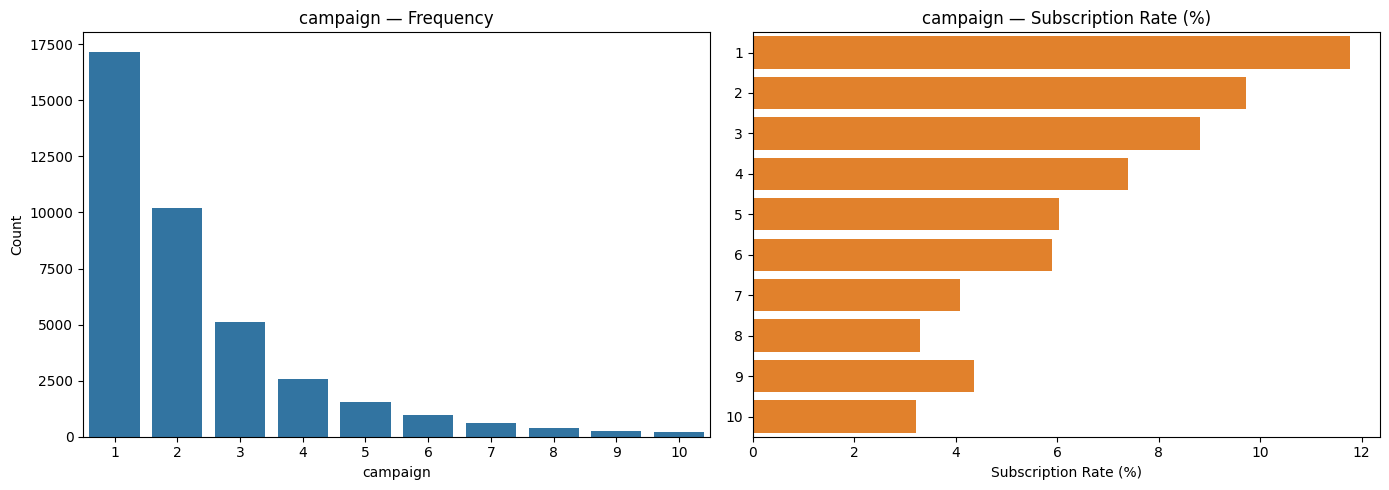

In [39]:
campaign_order = sorted(df['campaign'].unique())
plot_freq_rate('campaign', order=campaign_order, rot_freq=0)

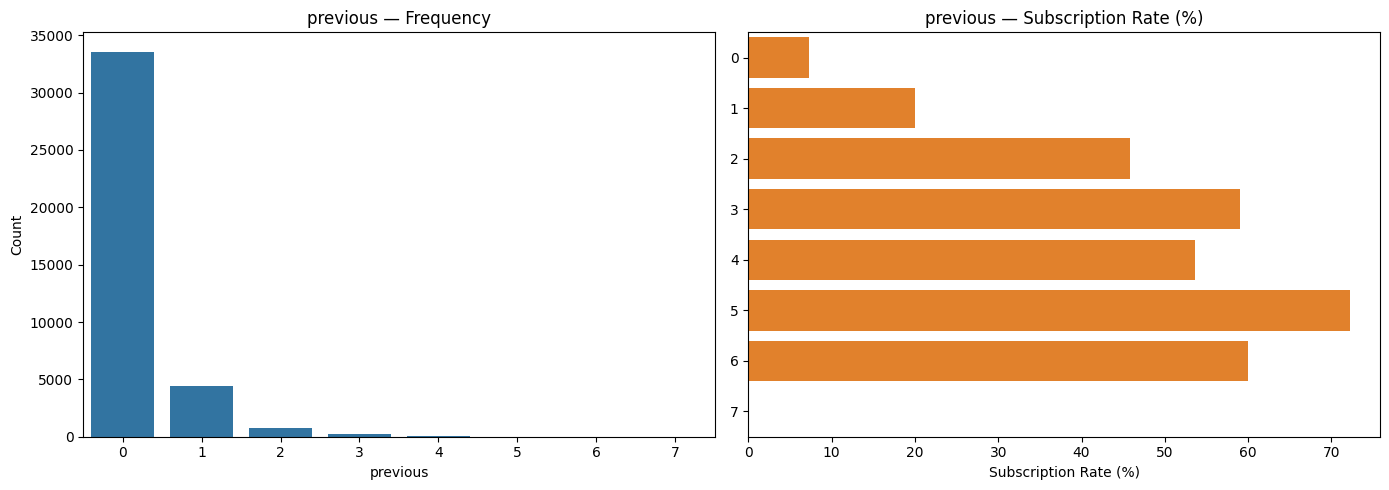

In [40]:
previous_order = sorted(df['previous'].unique())
plot_freq_rate('previous', order=previous_order, rot_freq=0)

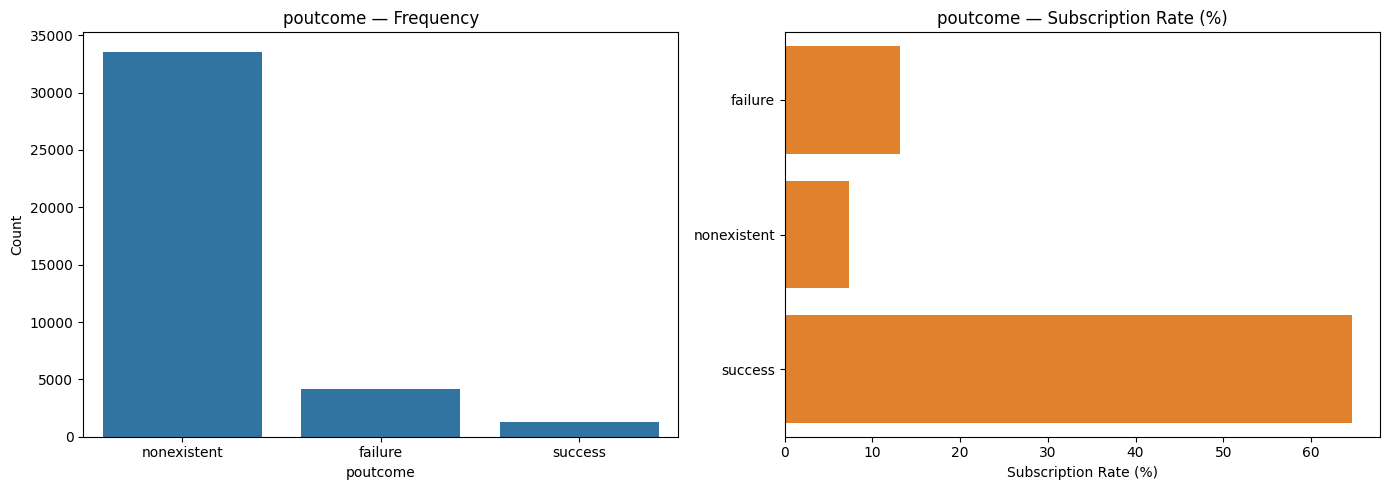

In [41]:
plot_freq_rate('poutcome', rot_freq=0)

- `campaign` --> customers who have been contacted less than 4 times for this campaign tend to subscribe to deposit more
- `previous` --> Majority of customers subscribe to deposit on the fifth contact before the current campaign
- `poutcome` --> Majority of customers who have subscribed deposit previously are willing to subscribe in the next campaign.

#### 2.4.7 Socioeconomic factors (Univariate)

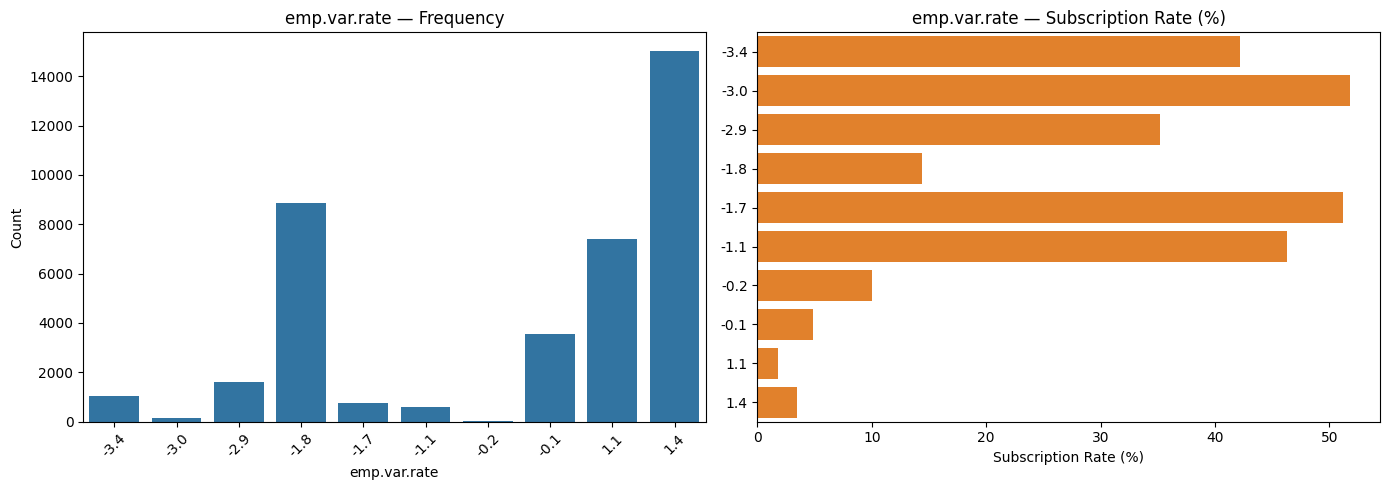

In [42]:
emp_order = sorted(df['emp.var.rate'].unique())
plot_freq_rate('emp.var.rate', order=emp_order, rot_freq=45)

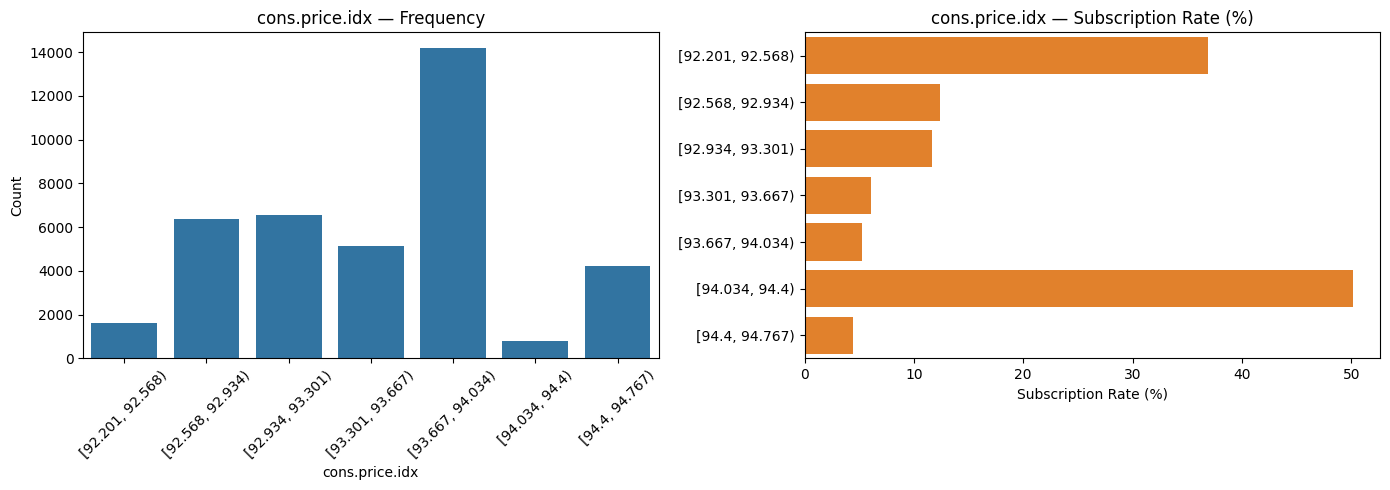

In [43]:
cpi_bins = np.linspace(df['cons.price.idx'].min(), df['cons.price.idx'].max(), 8)
plot_freq_rate('cons.price.idx', bins=cpi_bins, rot_freq=45)

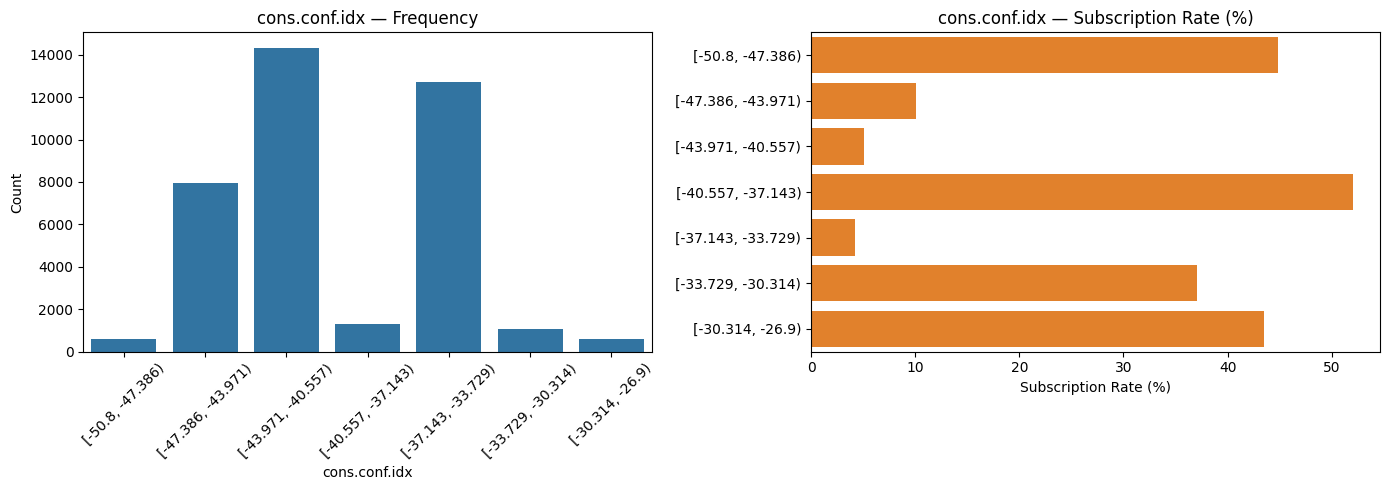

In [44]:
cci_bins = np.linspace(df['cons.conf.idx'].min(), df['cons.conf.idx'].max(), 8)
plot_freq_rate('cons.conf.idx', bins=cci_bins, rot_freq=45)

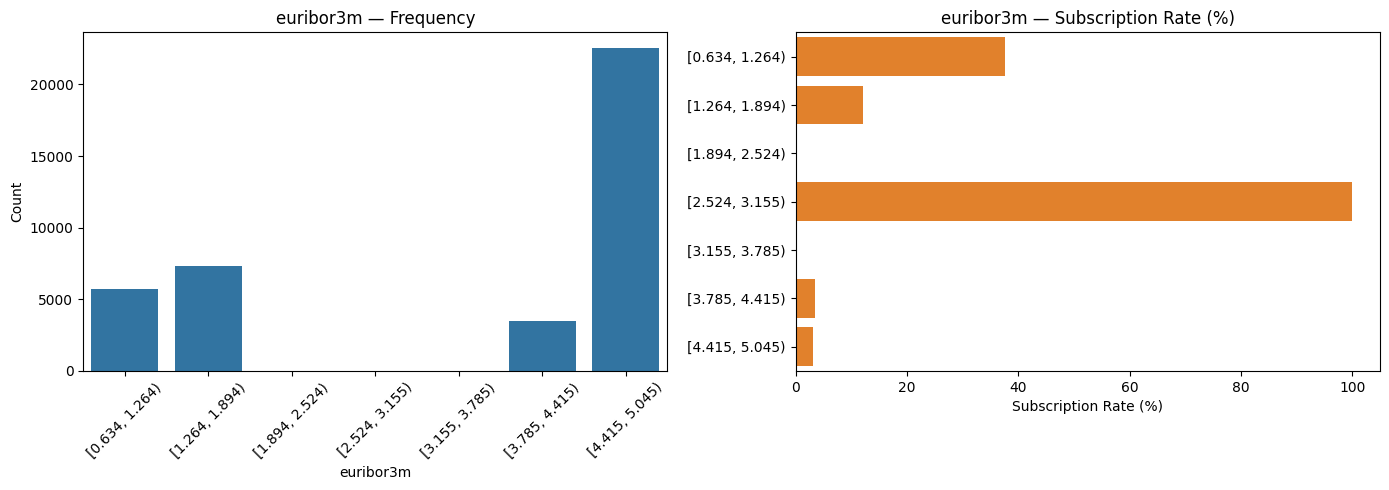

In [45]:
euribor_bins = np.linspace(df['euribor3m'].min(), df['euribor3m'].max(), 8)
plot_freq_rate('euribor3m', bins=euribor_bins, rot_freq=45)

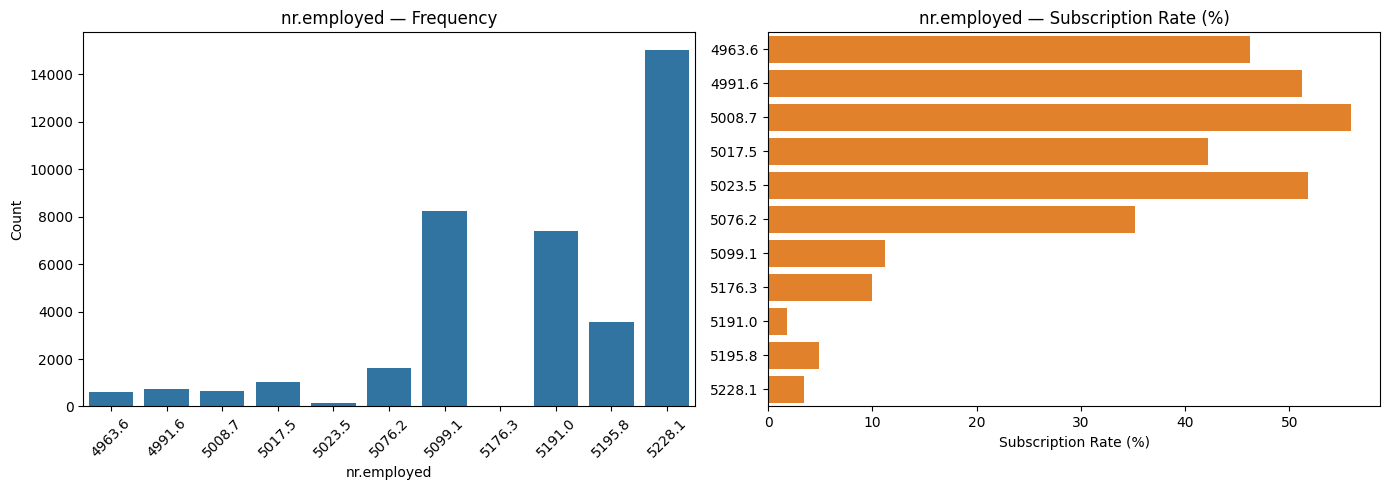

In [46]:
nremp_order = sorted(df['nr.employed'].unique())
plot_freq_rate('nr.employed', order=nremp_order, rot_freq=45)

- Subcriptions to deposit appear more frequent when economic indicators `employment variation rate` are lower and
`number employment` higher

- `euribor3m` --> The highest proportion of success deposits occurs when the interest rate is higher

- `cons.conf.idx` --> Subcriptions cluster at specific index, suggesting that middle-to-low confidence levels may drive people toward the perceived safety of a term deposit

- `cons.price.idx` --> Customers with the CPI of around 93 and around 94 shows higher proportion of subscribing deposits

**Bivariate Distribution of Target variable and Features**

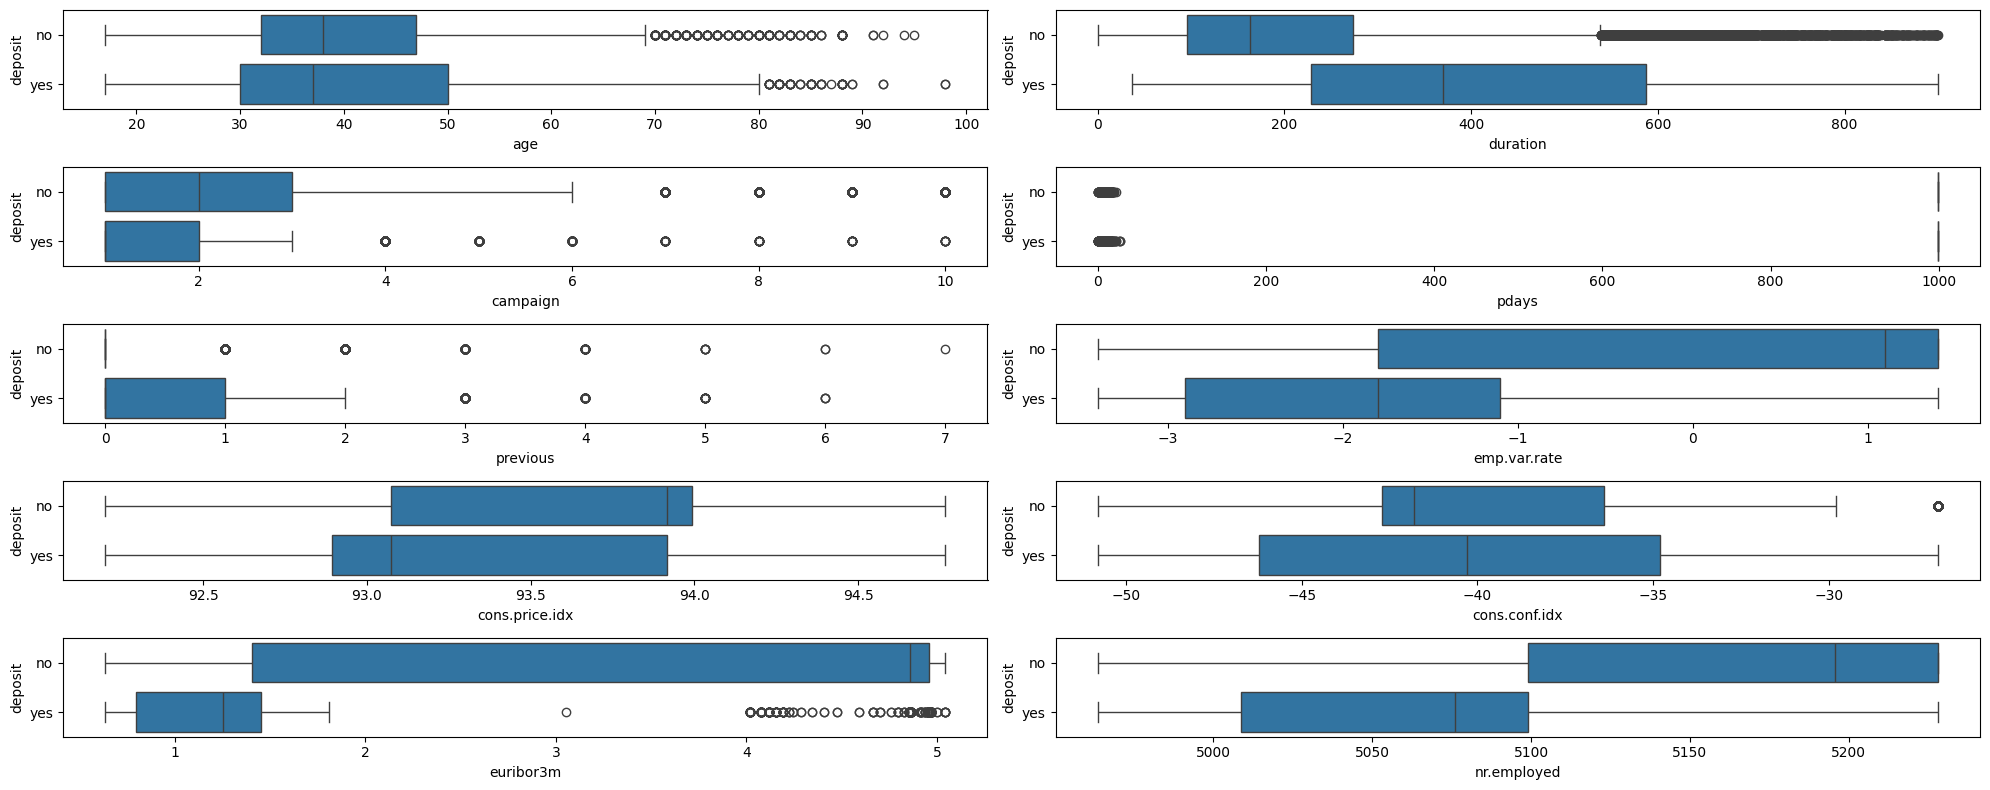

In [47]:
fig, axes = plt.subplots(5, 2, figsize=(20, 8))
ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10 = axes.flatten()
sns.boxplot(data=df, x='age',y='deposit',ax=ax1)
sns.boxplot(data=df, x='duration',y='deposit',ax=ax2)
sns.boxplot(data=df, x='campaign',y='deposit',ax=ax3)
sns.boxplot(data=df, x='pdays',y='deposit',ax=ax4)
sns.boxplot(data=df, x='previous',y='deposit',ax=ax5)
sns.boxplot(data=df, x='emp.var.rate',y='deposit',ax=ax6)
sns.boxplot(data=df, x='cons.price.idx',y='deposit',ax=ax7)
sns.boxplot(data=df, x='cons.conf.idx',y='deposit',ax=ax8)
sns.boxplot(data=df, x='euribor3m',y='deposit',ax=ax9)
sns.boxplot(data=df, x='nr.employed',y='deposit',ax=ax10)

plt.tight_layout()
plt.show()

The farther the median and IQR, the higher the discriminative power.
- `duration`, `euribor`, and `emp.var.rate`, `cons.price.idx` and `nr.employ` have high discriminative power.
- `age`, `previous`, `campaign`, and `pdays` have high overlap distributions  (low discriminative power) followed by `cons.conf.idx` overlapping moderately

### 2.5 Analysis of the Impact of the Financial Crisis on Term-Deposit Subscriptions in Portuguese Bank

In [48]:
df_analysis = df.copy()

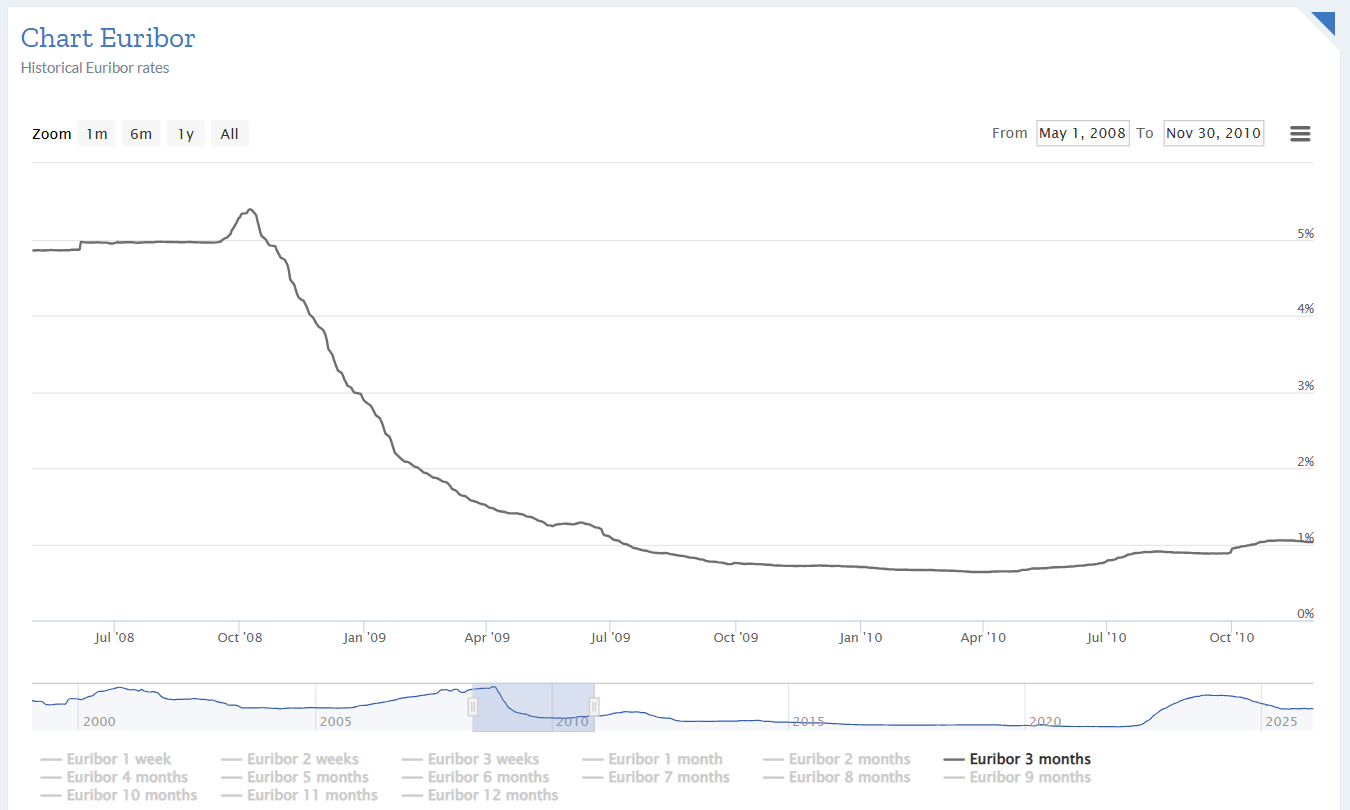

- Pre-crisis interest rate: The rate maintained a steady percentage near 5%, indicating a high-interest environment prior to the global financial crash

- Peak interest rate: A sharp spike in October 2008, likely driven by the immedicate liquidity crisis

- Collapse interest rate: The rate plummeting until mid-2009 from 5% to 1% in less than a year

- Early recovery: Toward the end of 2010, an upward trend is visible, signaling a cautious return to market

Time series  is needed to support this analysis, therefore the existing data is combined with [`euribor3m` data](https://www.euribor-rates.eu/en/euribor-charts/) and `cons.price.idx`-`cons.conf.idx` quarterly data to determine the data year

In [49]:
df_analysis.groupby('month')['euribor3m'].unique()

,euribor3m
month,
jan,[]
feb,[]
mar,"[1.811, 1.799, 1.778, 1.757, 1.726, 1.703, 1.687, 1.663, 1.65, 1.64, 1.629, 1.614, 1.602, 1.584, 1.574, 1.56, 1.556, 1.548, 1.538, 1.531, 1.52, 1.51, 0.655, 0.654, 0.653, 0.652, 0.651, 0.65, 0.649, 0.646, 0.644, 0.643, 0.639, 0.637, 0.635, 0.636, 0.634]"
apr,"[1.498, 1.483, 1.479, 1.466, 1.453, 1.445, 1.435, 1.423, 1.415, 1.41, 1.405, 1.406, 1.4, 1.392, 1.384, 1.372, 1.365, 0.635, 0.638, 0.64, 0.642, 0.644, 0.643, 0.645, 0.646, 0.654, 0.659, 0.663]"
may,"[4.857, 4.856, 4.855, 4.859, 4.86, 4.858, 4.864, 1.354, 1.344, 1.334, 1.327, 1.313, 1.299, 1.291, 1.281, 1.266, 1.25, 1.244, 1.259, 1.264, 1.27, 0.668, 0.672, 0.677, 0.682, 0.683, 0.684, 0.685, 0.688, 0.69, 0.692, 0.695, 0.697, 0.699, 0.701]"
jun,"[4.865, 4.864, 4.866, 4.967, 4.961, 4.959, 4.958, 4.96, 4.962, 4.955, 4.947, 1.266, 1.262, 1.26, 1.268, 1.281, 1.286, 1.252, 1.244, 1.235, 1.224, 1.215, 1.206, 1.099, 0.702, 0.704, 0.707, 0.711, 0.713, 0.715, 0.719, 0.72, 0.723, 0.727, 0.729, 0.732, 0.733, 0.737, 0.739, 0.742, 0.748, 0.754, 0.761, 0.767]"
jul,"[4.955, 4.956, 4.966, 4.959, 4.96, 4.962, 4.963, 4.961, 4.957, 4.958, 4.968, 1.085, 1.072, 1.059, 1.048, 1.044, 1.029, 1.018, 1.007, 0.996, 0.979, 0.969, 0.944, 0.937, 0.927, 0.921, 0.914, 0.908, 0.903, 0.899, 0.782, 0.79, 0.793, 0.797, 0.802, 0.81, 0.822, 0.827, 0.835, 0.84, 0.846, 0.861, 0.87, 0.876, 0.881, 0.884, 0.885, 0.889, 0.893, 0.896]"
aug,"[4.97, 4.968, 4.967, 4.966, 4.965, 4.964, 4.963, 4.962, 0.884, 0.883, 0.881, 0.879, 0.873, 0.869, 0.861, 0.859, 0.854, 0.851, 0.849, 0.843, 0.838, 0.834, 0.829, 0.825, 0.821, 0.898, 0.899, 0.9, 0.904, 0.905, 0.903, 0.896, 0.895, 0.894, 0.891, 0.89, 0.889, 0.888, 0.886]"
sep,"[0.819, 0.813, 0.809, 0.803, 0.797, 0.788, 0.781, 0.778, 0.773, 0.771, 0.77, 0.768, 0.766, 0.762, 0.755, 0.749, 0.743, 0.741, 0.739, 0.75, 0.753, 0.886, 0.884, 0.883, 0.882, 0.881, 0.88, 0.879, 0.878, 0.877, 0.876]"


In [50]:
df_analysis['year'] = np.nan


# MAY
may = df_analysis['month'] == 'may'
df_analysis.loc[may & df_analysis['euribor3m'].between(4, 5), 'year'] = 2008
df_analysis.loc[may & df_analysis['euribor3m'].between(1.1, 1.4), 'year'] = 2009
df_analysis.loc[may & df_analysis['euribor3m'].between(0.5, 0.8), 'year'] = 2010

# MAR
mar = df_analysis['month'] == 'mar'
df_analysis.loc[mar & df_analysis['euribor3m'].between(1.4, 2), 'year'] = 2009
df_analysis.loc[mar & ~df_analysis['euribor3m'].between(1.4, 2), 'year'] = 2010

# APR
apr = df_analysis['month'] == 'apr'
df_analysis.loc[apr & df_analysis['euribor3m'].between(1.3, 1.5), 'year'] = 2009
df_analysis.loc[apr & ~df_analysis['euribor3m'].between(1.3, 1.5), 'year'] = 2010

# JUL
jul = df_analysis['month'] == 'jul'
df_analysis.loc[jul & df_analysis['euribor3m'].between(4.8, 5), 'year'] = 2008
df_analysis.loc[jul & np.isclose(df_analysis['emp.var.rate'], -2.9), 'year'] = 2009
df_analysis.loc[jul & np.isclose(df_analysis['emp.var.rate'], -1.7), 'year'] = 2010

# JUN
jun = df_analysis['month'] == 'jun'
df_analysis.loc[jun & df_analysis['euribor3m'].between(4.8, 5), 'year'] = 2008
df_analysis.loc[jun & df_analysis['euribor3m'].between(1, 1.3), 'year'] = 2009
df_analysis.loc[jun & df_analysis['euribor3m'].between(0.7, 0.8), 'year'] = 2010

# AUG
aug = df_analysis['month'] == 'aug'
df_analysis.loc[aug & df_analysis['euribor3m'].between(4.8, 5), 'year'] = 2008
df_analysis.loc[aug & np.isclose(df_analysis['emp.var.rate'], -2.9), 'year'] = 2009
df_analysis.loc[aug & np.isclose(df_analysis['emp.var.rate'], -1.7), 'year'] = 2010

# SEPT
sep = df_analysis['month'] == 'sep'
df_analysis.loc[sep & df_analysis['euribor3m'].between(0.7, 0.82), 'year'] = 2009
df_analysis.loc[sep & ~df_analysis['euribor3m'].between(0.7, 0.82), 'year'] = 2010

# OCT
oct = df_analysis['month'] == 'oct'
df_analysis.loc[oct & df_analysis['euribor3m'].between(4.7, 5.1), 'year'] = 2008
df_analysis.loc[oct & df_analysis['euribor3m'].between(0.7, 0.8), 'year'] = 2009
df_analysis.loc[oct & df_analysis['euribor3m'].between(0.9, 1.1), 'year'] = 2010

# NOV
nov = df_analysis['month'] == 'nov'
df_analysis.loc[nov & df_analysis['euribor3m'].between(3, 5), 'year'] = 2008
df_analysis.loc[nov & np.isclose(df_analysis['emp.var.rate'], -3.4), 'year'] = 2009
df_analysis.loc[nov & np.isclose(df_analysis['emp.var.rate'], -1.1), 'year'] = 2010

# DEC
dec = df_analysis['month'] == 'dec'
df_analysis.loc[dec & df_analysis['euribor3m'].between(3, 4), 'year'] = 2008
df_analysis.loc[dec & ~df_analysis['euribor3m'].between(3, 4), 'year'] = 2009


df_analysis['year'] = df_analysis['year'].astype('Int64')



In [51]:
df_analysis.head(5)

,index,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposit,year
0,0,56,housemaid,married,basic 4 years,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008
1,1,57,services,married,high school,NaN,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008
2,2,37,services,married,high school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008
3,3,40,admin,married,basic 6 years,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008
4,4,56,services,married,high school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,2008


In [52]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

df_analysis['month'] = pd.Categorical(df_analysis['month'],
                                   categories=month_order,
                                   ordered=True)
df_analysis['date'] = pd.to_datetime(
    df_analysis['year'].astype(str) + '-' +
    df_analysis['month'].astype(str),
    format='%Y-%b'
)

df_analysis = df_analysis.sort_values('date')

#### 2.5.1 Socioeconomic Factors

##### Euribor

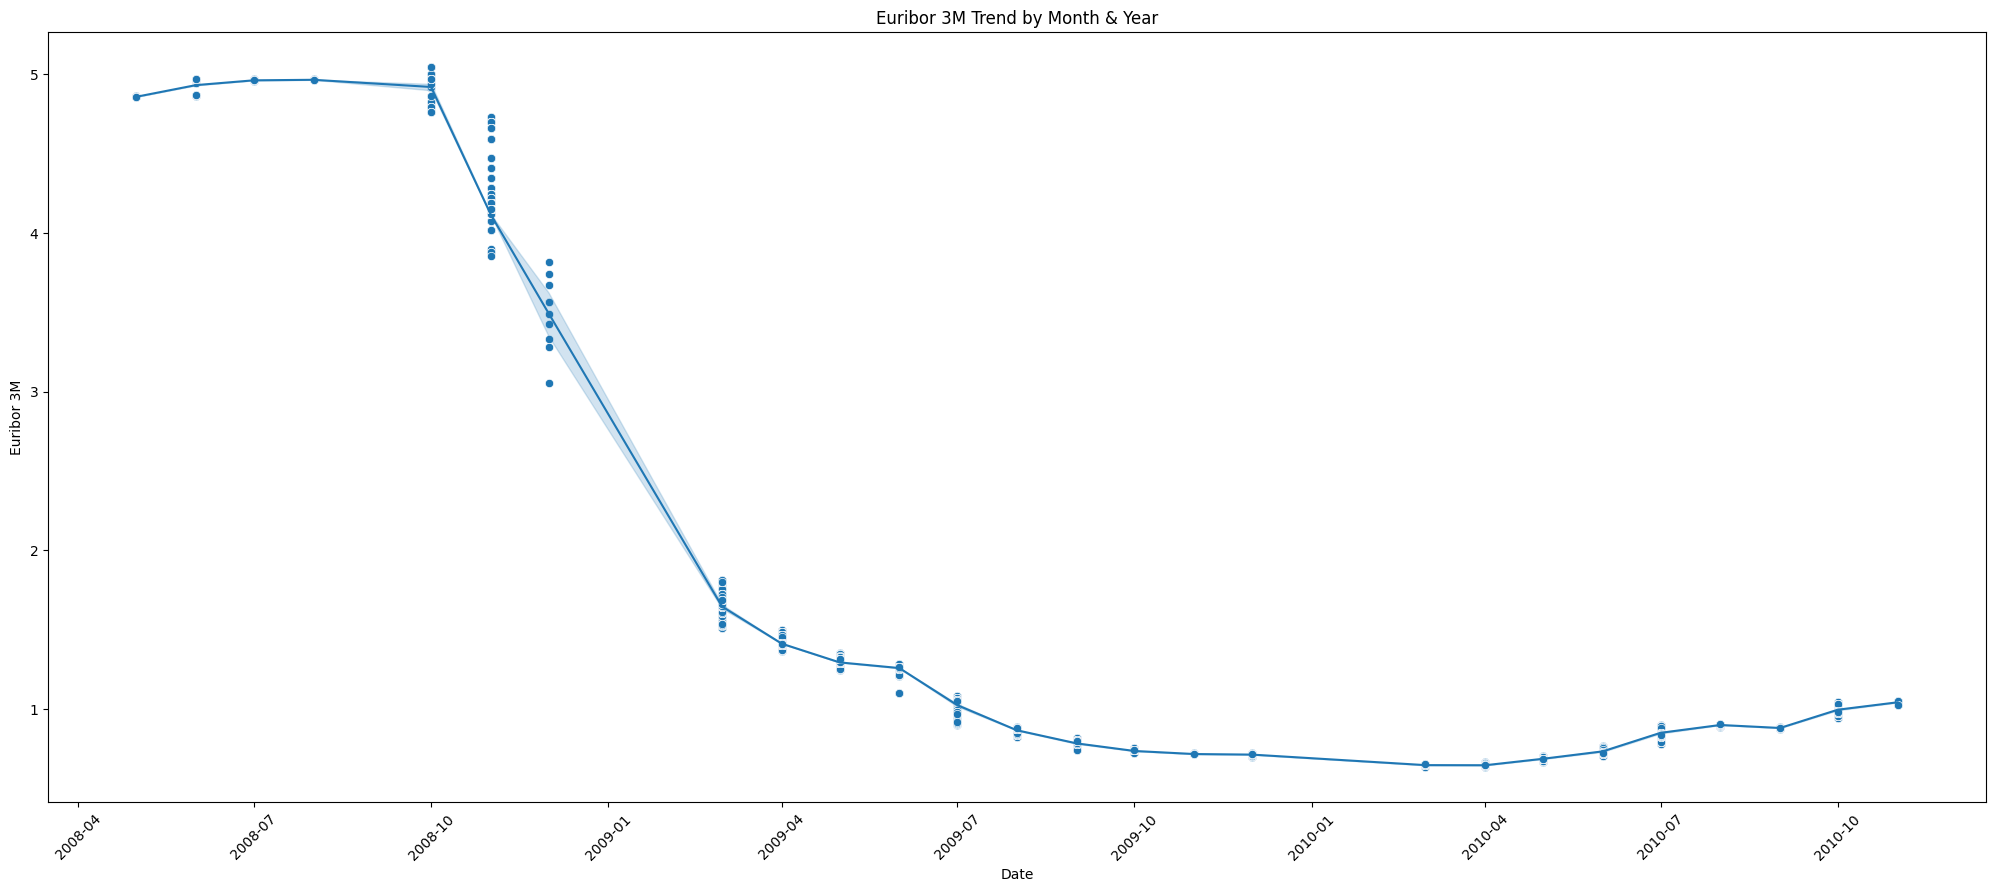

In [53]:
plt.figure(figsize = (25,10))

sns.scatterplot(x = 'date' , y = 'euribor3m', data = df_analysis)
sns.lineplot(x = 'date', y = 'euribor3m', data = df_analysis)

plt.xticks(rotation=45)

plt.title("Euribor 3M Trend by Month & Year")
plt.xlabel("Date")
plt.ylabel("Euribor 3M")
plt.show()

The Euribor time series graph illustrates the interest rate levels at the time when the marketing campaigns were conducted. Based on the trend pattern and the corresponding timeline, the data reflects the impact of the European financial crisis, which also affected the Portuguese banking sector. Therefore, the time series can be segmented into three distinct phases: pre-crisis, crisis, and recovery.

This phase classification aligns with the [IMF's assessment](https://www.imf.org/en/news/articles/2015/09/14/01/49/pr09332?utm_source=chatgpt.com) that Europe experienced its deepest contraction during late 2008 and early 2009, reached its trough around mid-2009, and entered a slow and fragile recovery thereafter.

In [54]:
df_analysis['phase'] = 'recovery'

df_analysis.loc[df_analysis['euribor3m'] >= 4.5, 'phase'] = 'pre_crisis'

df_analysis.loc[
    (df_analysis['euribor3m'].between(1.070, 4.5)) &
    (df_analysis['date'] < '2009-08-01'),
    'phase'
] = 'crisis'


- The graph shows that in December 2008, Euribor exhibited a relatively wide range of variation.
- The line representing the target variable (deposit) indicates that some customers subscribed to term deposits when interest rates were lower, which causes the line to slope downward.

##### Employment Variation Rate

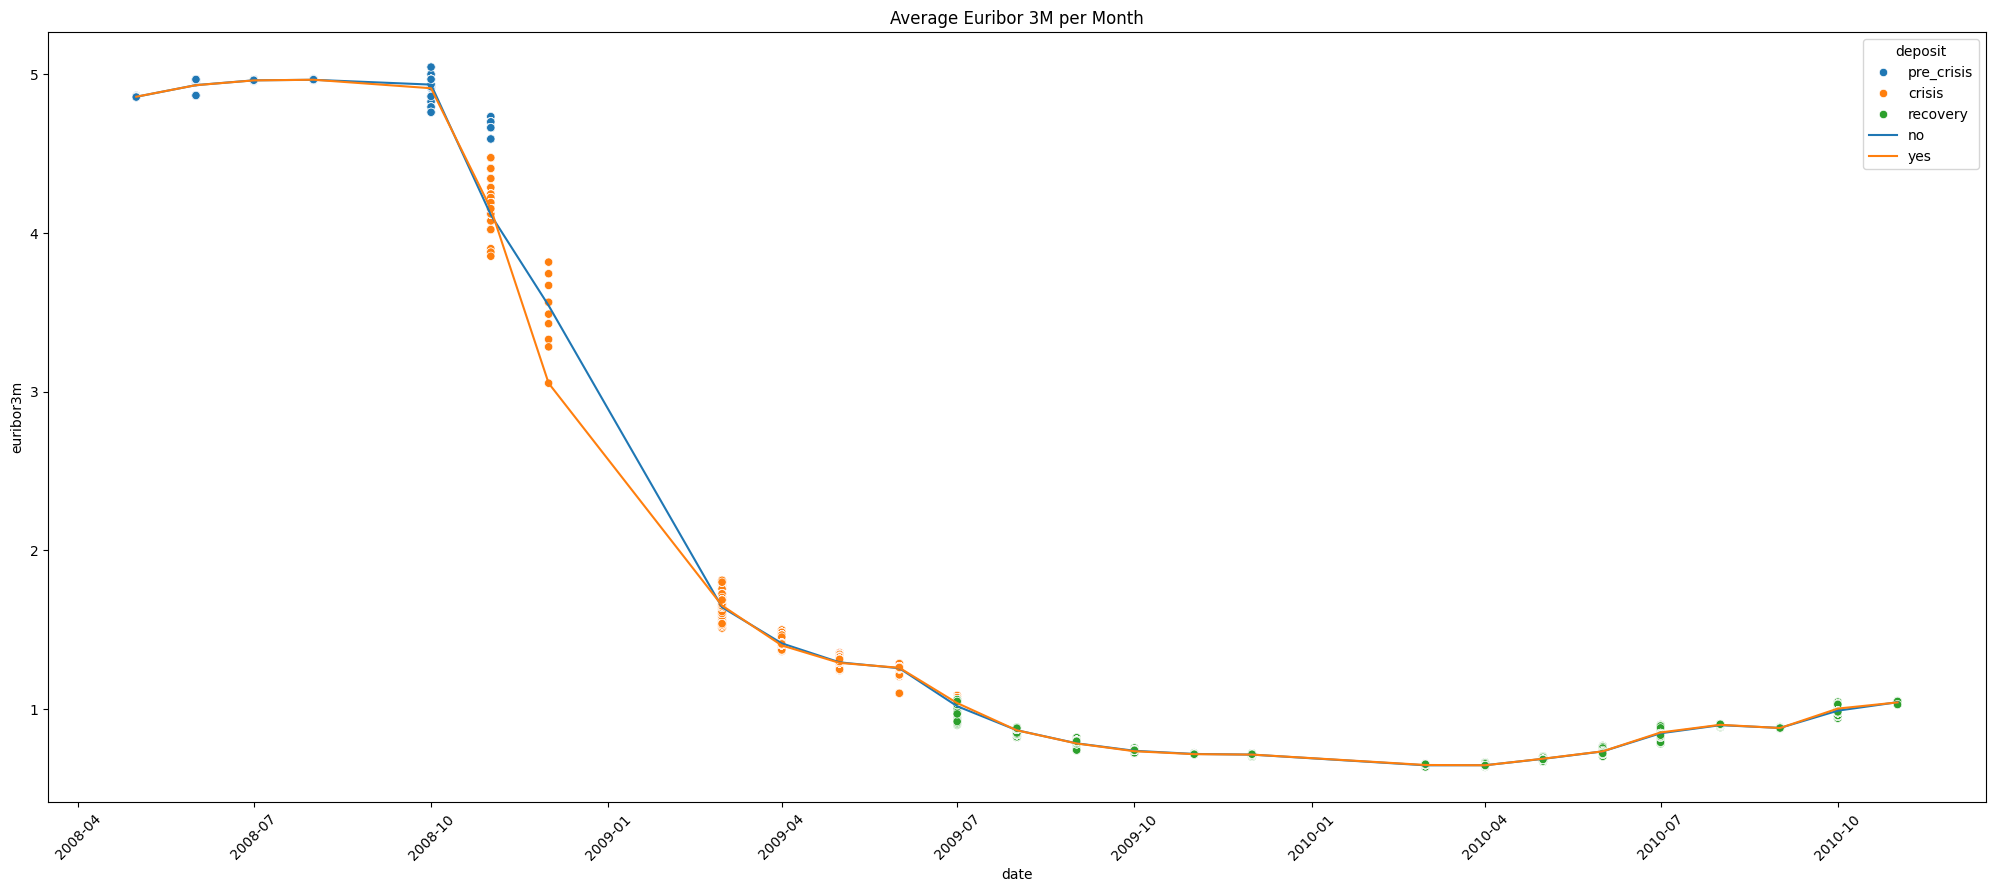

In [55]:
monthly_avg = (
    df_analysis.groupby(['date','deposit'])['euribor3m'].mean()
    .reset_index())

plt.figure(figsize=(25,10))

sns.scatterplot(x = 'date' , y = 'euribor3m',hue='phase', data = df_analysis)
sns.lineplot(data=monthly_avg, x='date', y='euribor3m', hue='deposit')

plt.title("Average Euribor 3M per Month")
plt.xticks(rotation=45)
plt.show()


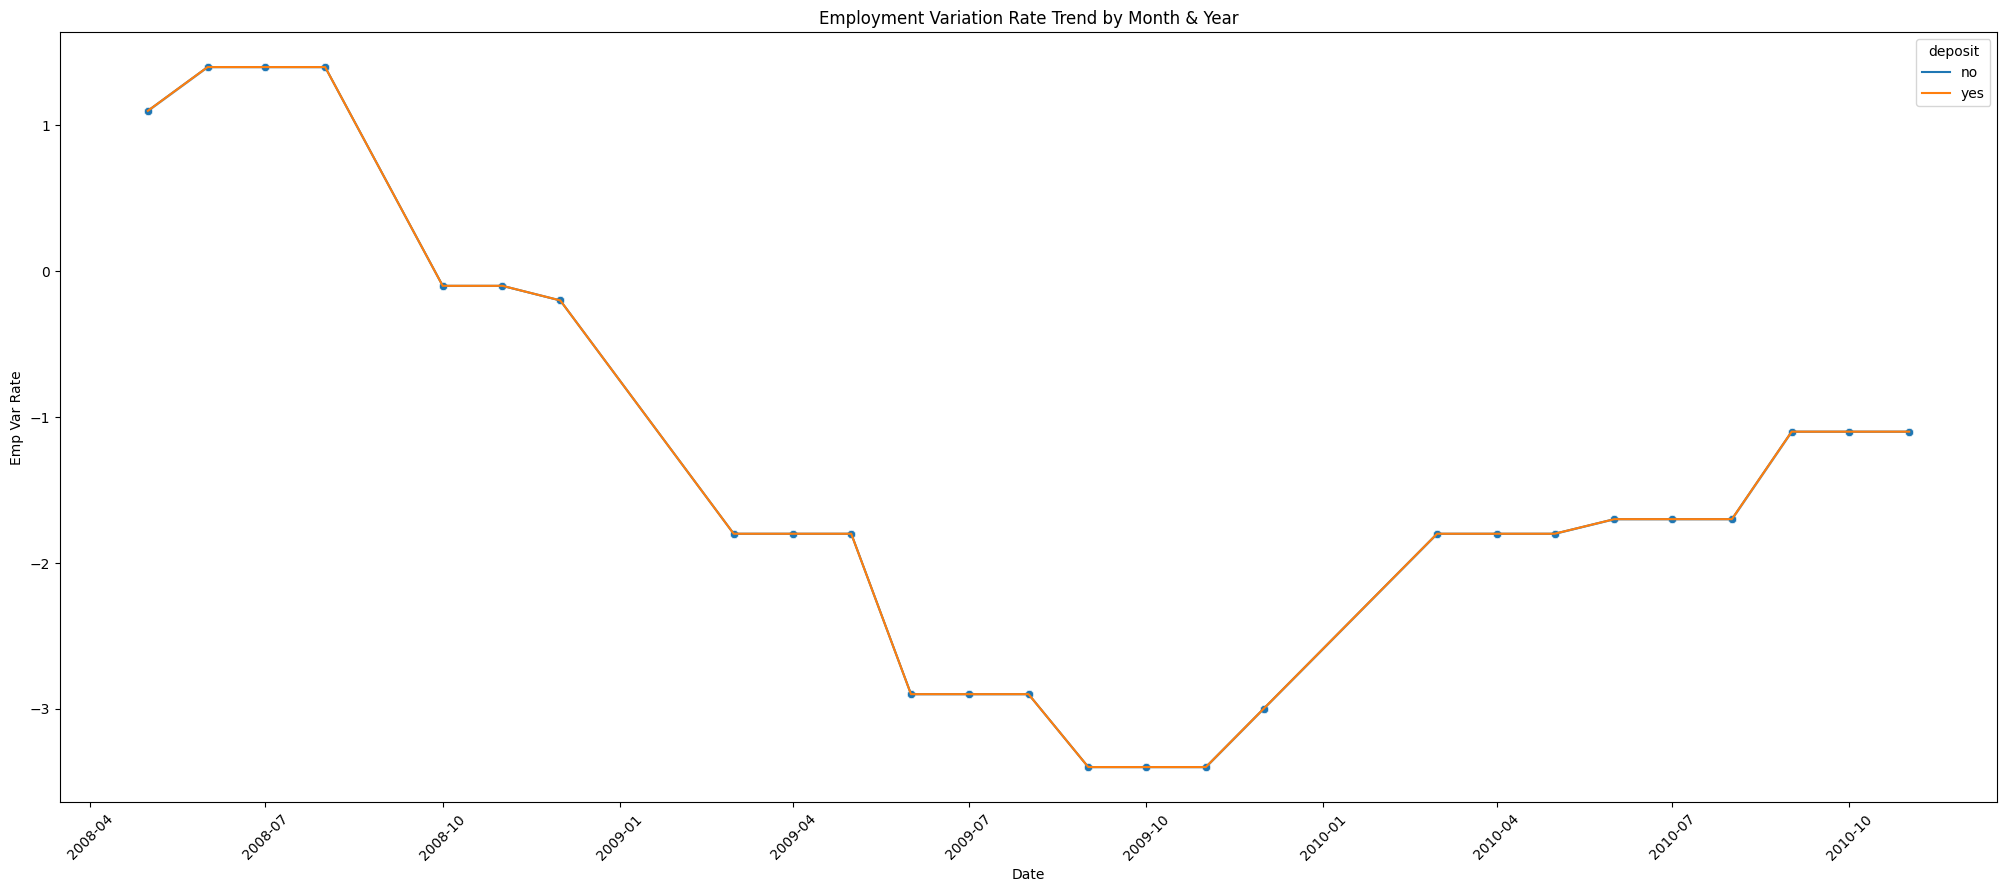

In [56]:
plt.figure(figsize = (25,10))

sns.scatterplot(x = 'date' , y = 'emp.var.rate', data = df_analysis)
sns.lineplot(x = 'date', y = 'emp.var.rate', data = df_analysis, hue='deposit')

plt.xticks(rotation=45)

plt.title("Employment Variation Rate Trend by Month & Year")
plt.xlabel("Date")
plt.ylabel("Emp Var Rate")
plt.show()

- The employment variation rate trend moves closely in line with the Euribor interest rate pattern discussed earlier
- During the crisis period, when Euribor declined sharply, the employment variation rate also dropped significantly. This reflects the decadency in labor market conditions, as the crisis led to reduced business activity and rising unemployment across Europe
- As the recovery phase began, although Euribor remained relatively low compared to pre-crisis levels, the employment variation rate gradually improved. This suggests that labor market conditions started to stabilize and employment began to recover, indicating the early stages of economic recovery.

##### Number of Employees

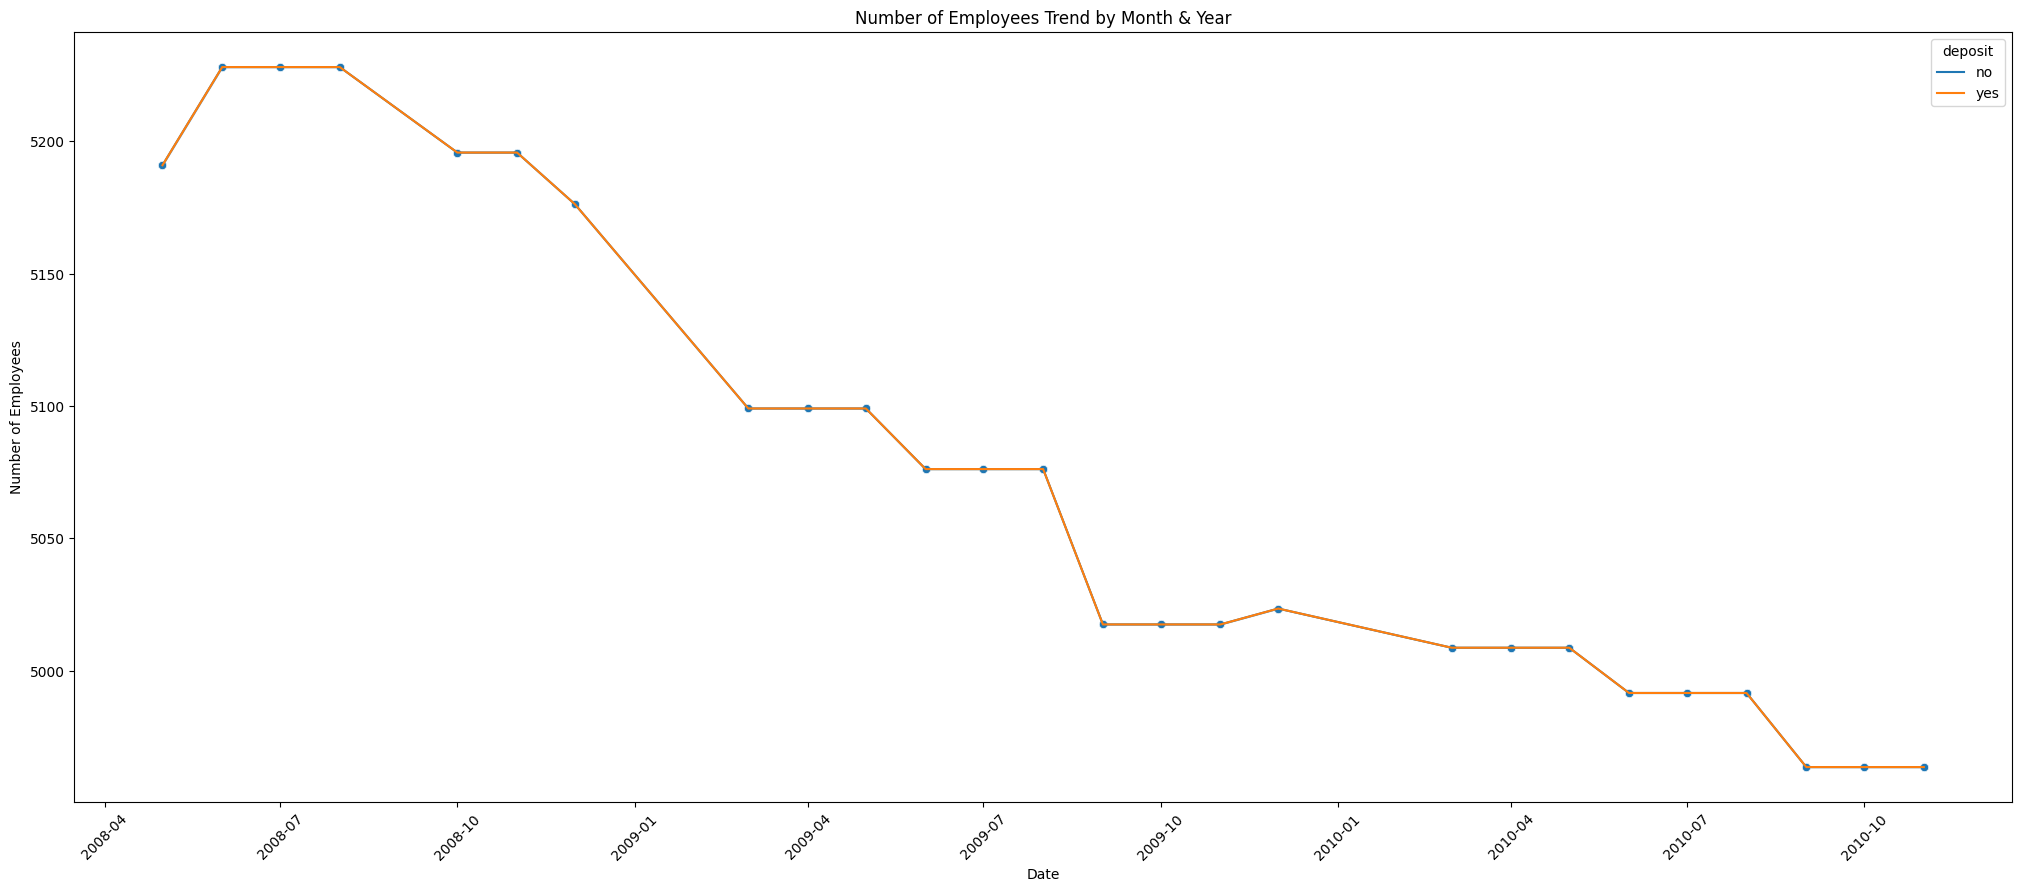

In [57]:
plt.figure(figsize = (25,10))

sns.scatterplot(x = 'date' , y = 'nr.employed', data = df_analysis)
sns.lineplot(x = 'date', y = 'nr.employed', data = df_analysis, hue='deposit')

plt.xticks(rotation=45)

plt.title("Number of Employees Trend by Month & Year")
plt.xlabel("Date")
plt.ylabel("Number of Employees")
plt.show()

- The variable nr.employed represents the quarterly average number of employed individuals in Portugal, measured in thousands of persons. This definition is consistent with official employment statistics published for Portugal such as [CEIC](https://www.ceicdata.com/en/portugal/labour-force-survey-employment-by-age-and-sex/employment) surveys.
- The trend in the number of employees is consistent with the patterns observed in both the Euribor rate and the employment variation rate.
- During the pre-crisis period, the number of employees remained relatively stable at a higher level, reflecting stronger economic conditions and higher interest rates.
- As the financial crisis Euribor declined sharply, while the employment variation rate turned significantly negative. This macroeconomic contraction is reflected in the steady decline in the number of employees, indicating layoffs and reduced hiring activity during the downturn.
- Unlike the employment variation rate which begins to improve during the recovery phase the total number of employees continues to decline or recovers more slowly. This is economically reasonable because employment levels are typically a lagging indicator. Even when interest rates remain low and economic conditions start stabilizing, firms tend to be cautious in rehiring until recovery becomes more sustainable.


##### Consumer Price Index

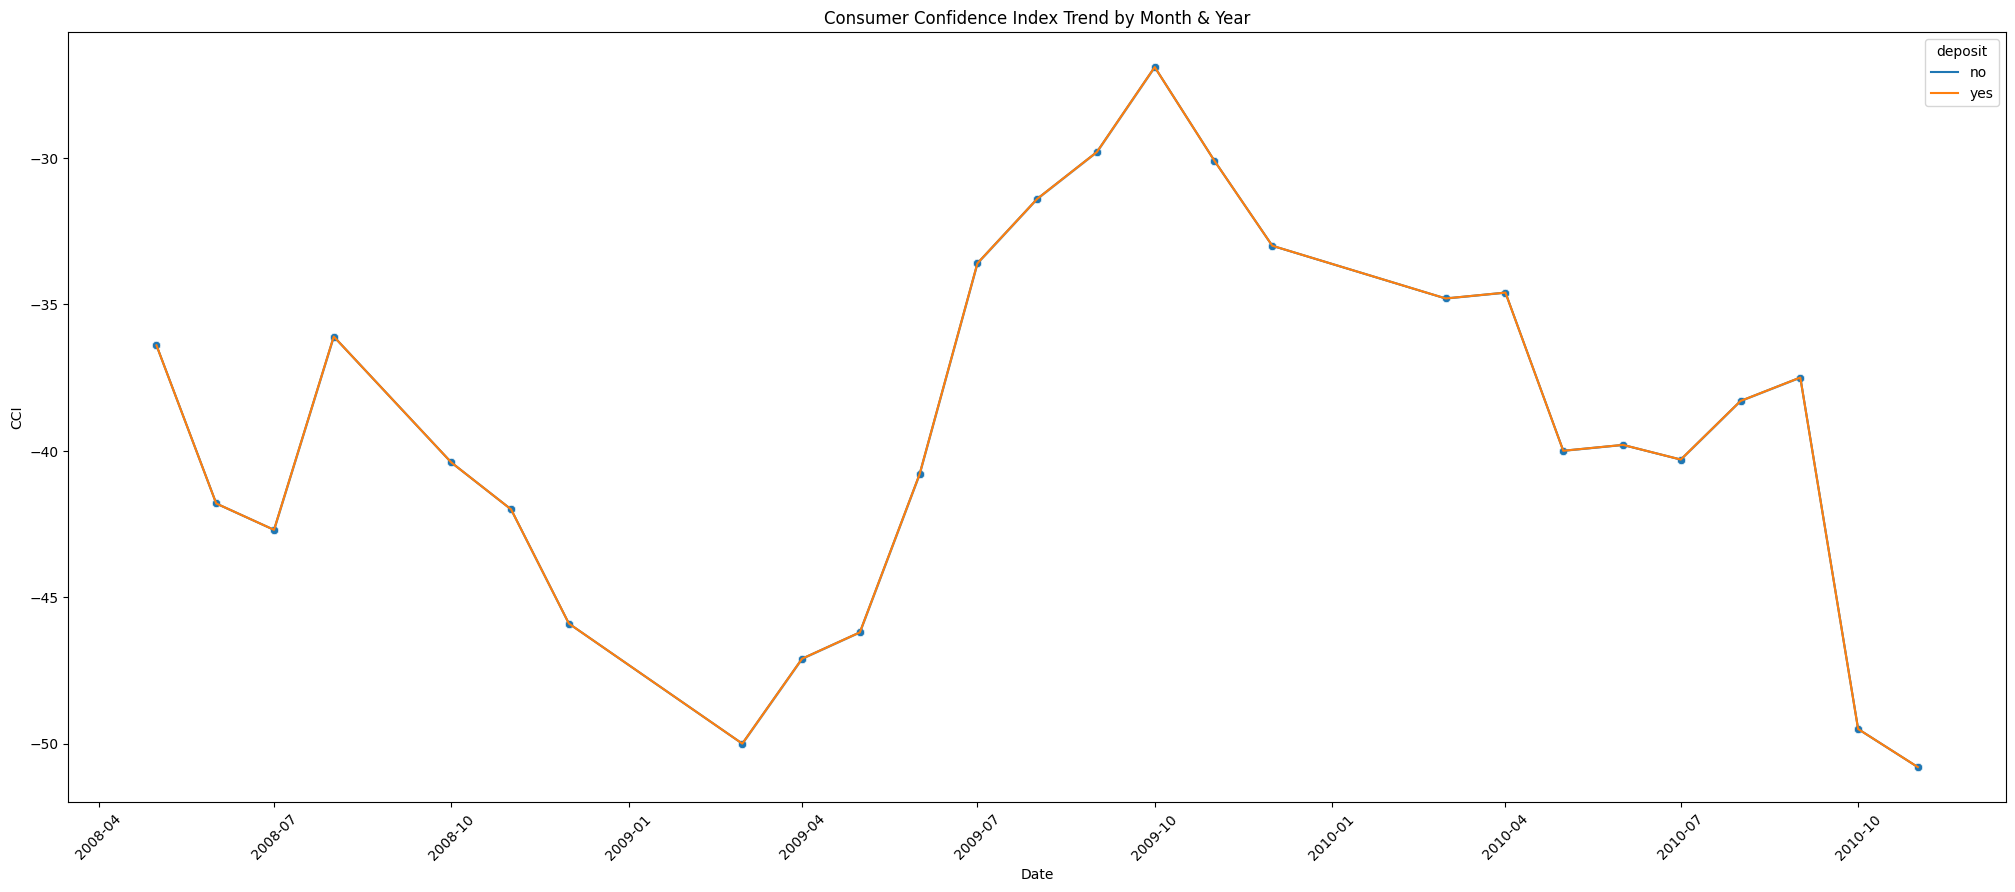

In [58]:
plt.figure(figsize = (25,10))

sns.scatterplot(x = 'date' , y = 'cons.conf.idx', data = df_analysis)
sns.lineplot(x = 'date', y = 'cons.conf.idx', data = df_analysis, hue='deposit')

plt.xticks(rotation=45)

plt.title("Consumer Confidence Index Trend by Month & Year")
plt.xlabel("Date")
plt.ylabel("CCI")
plt.show()

- The CCI shows a steady decline through 2008, reaching a low point in early 2009, which align with the broader macroeconomic downturn during the global financial crisis
- There was a rapid rebound in mid-2009, possibly reflecting temporary stabilization in economic expectations
- In 2010, the index becomes more volatile, reflecting an ongoing anxiety (likely tied to the onset of the European debt crisis)
- Overall, the chart suggests that variations in consumer confidence alone may not strongly differentiate subscription outcomes. Campaign success may be more influenced by factors such as outreach intensity or client-specific characteristics

##### Consumer Price Index

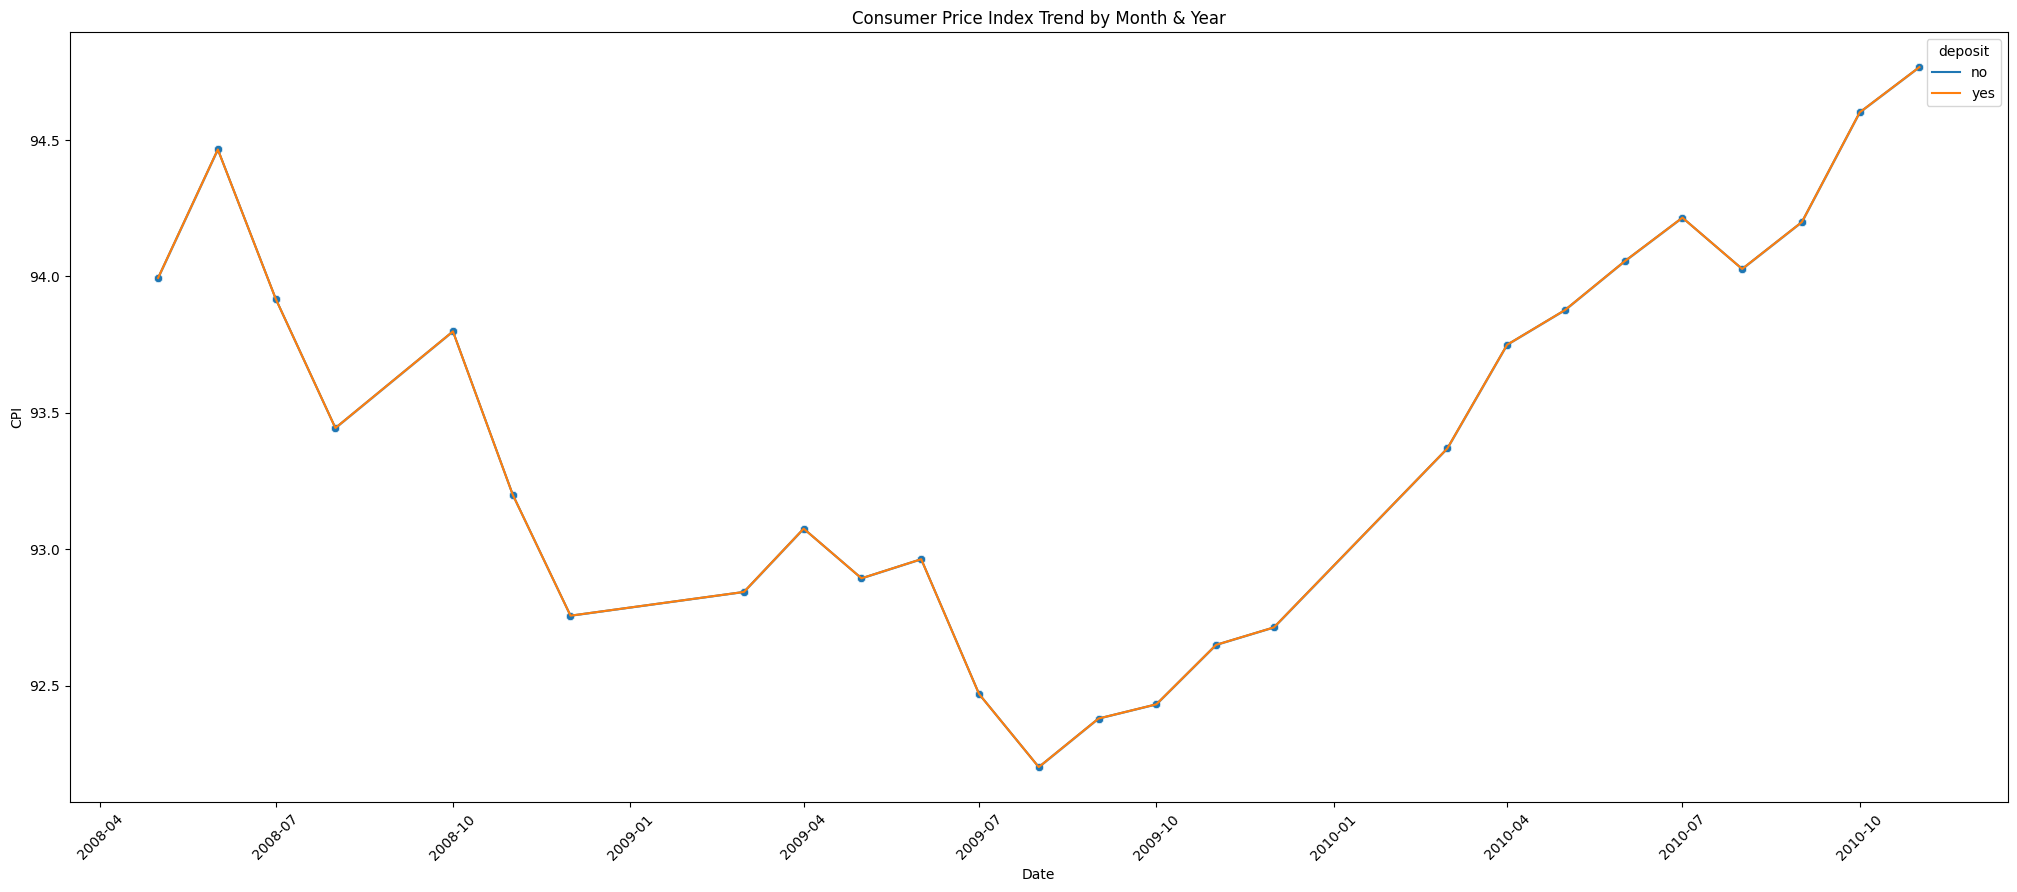

In [59]:
plt.figure(figsize = (25,10))

sns.scatterplot(x = 'date' , y = 'cons.price.idx', data = df_analysis)
sns.lineplot(x = 'date', y = 'cons.price.idx', data = df_analysis, hue='deposit')

plt.xticks(rotation=45)

plt.title("Consumer Price Index Trend by Month & Year")
plt.xlabel("Date")
plt.ylabel("CPI")
plt.show()

- The CPI experienced significant fluctuations in 2008

- A major downward trend occured in early 2009, coinciding with the broader economic contraction during the financial crisis

- During late 2009 to 2010 the CPI gradually increased, which may suggest improving economic conditions


##### Correlation Matrix

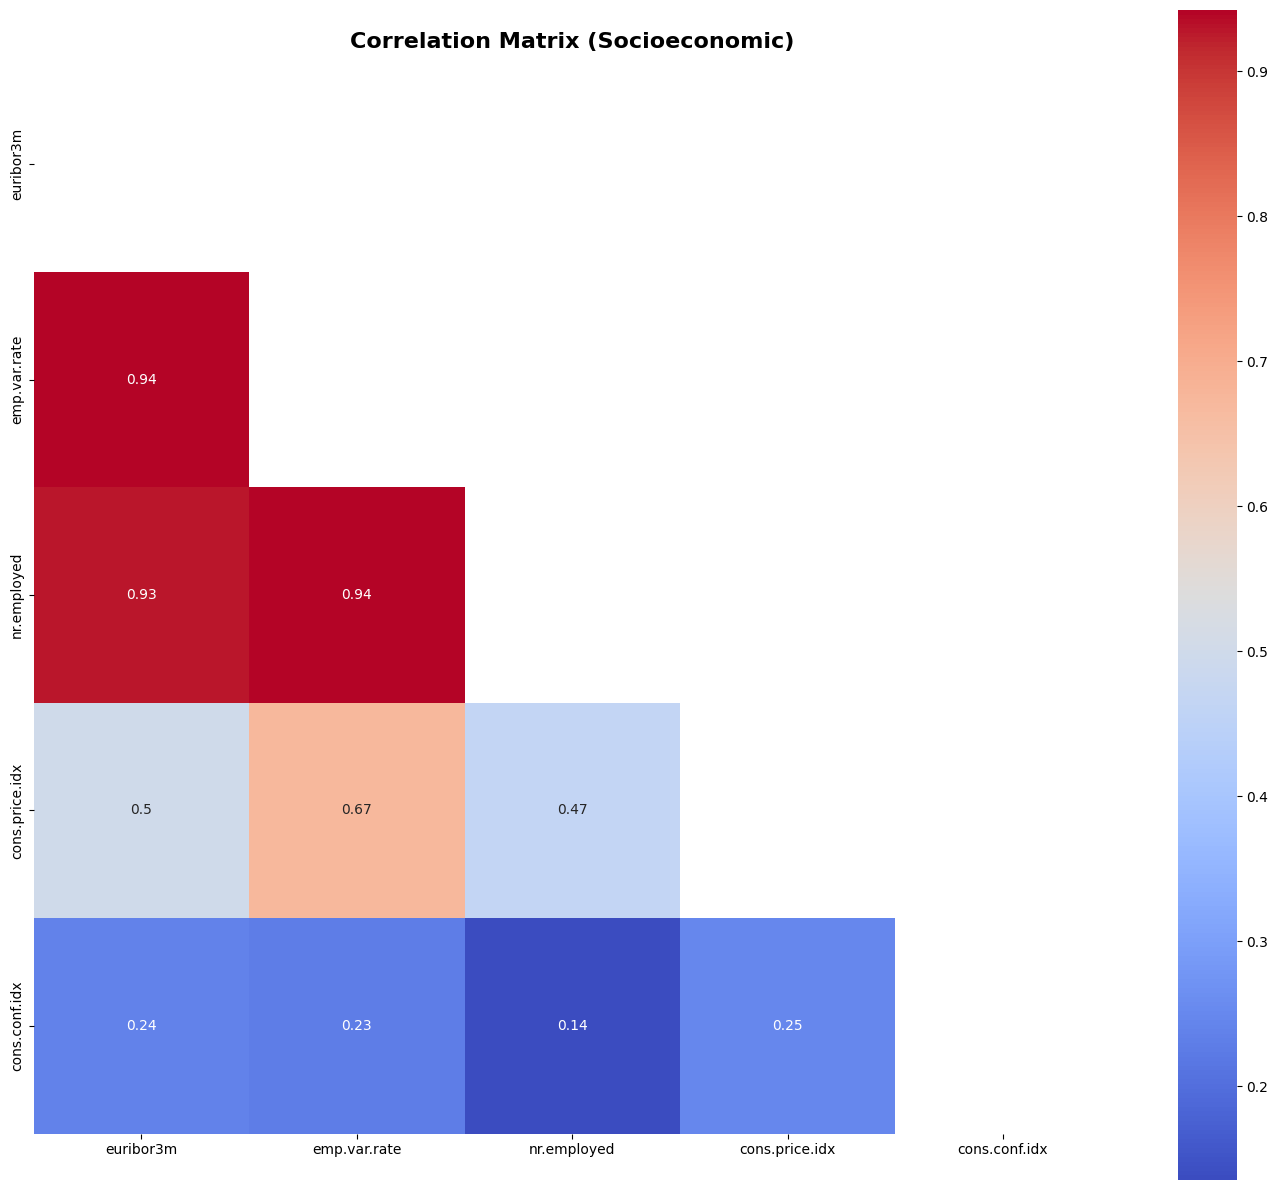

In [60]:
corr_analysis = df_analysis[['euribor3m','emp.var.rate',
             'nr.employed','cons.price.idx',
             'cons.conf.idx']].corr(method='spearman')
mask = np.triu(np.ones_like(corr_analysis, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr_analysis, annot=True, mask=mask, square=True, cmap='coolwarm')
plt.title('Correlation Matrix (Socioeconomic)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

- The correlation matrix shows strong macroeconomic relationships between :
  -  Euribor and employment - employment variation rate
  -  Euribor - number of employees
  - employment variation rate - number of employees.
- Moderate correlations are found between :
  - CPI - Euribor
  - CPI - employment variation rate.
- Meanwhile, the Consumer Confidence Index (CCI) exhibits weak correlations with all other variables. Additionally, CPI shows a relatively weak relationship with the number of employees.

#### 2.5.2 Deposit Subcription

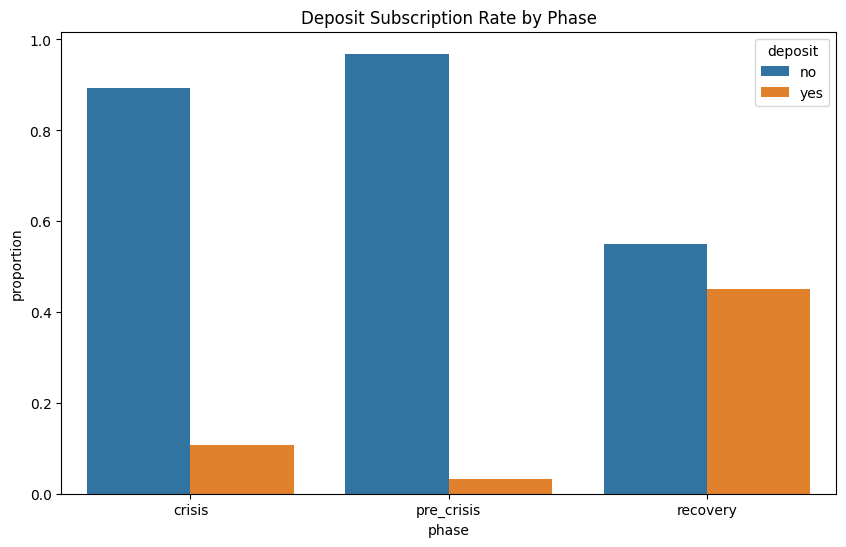

In [61]:
phase_rate_reset = (
    df_analysis
    .groupby('phase')['deposit']
    .value_counts(normalize=True)
    .reset_index(name='proportion')
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=phase_rate_reset,
    x='phase',
    y='proportion',
    hue='deposit'
)

plt.title("Deposit Subscription Rate by Phase")
plt.show()


In percentage terms, the chart shows that during the recovery phase, consumers had the highest subscription rate for term deposits compared to the crisis and pre-crisis phases.

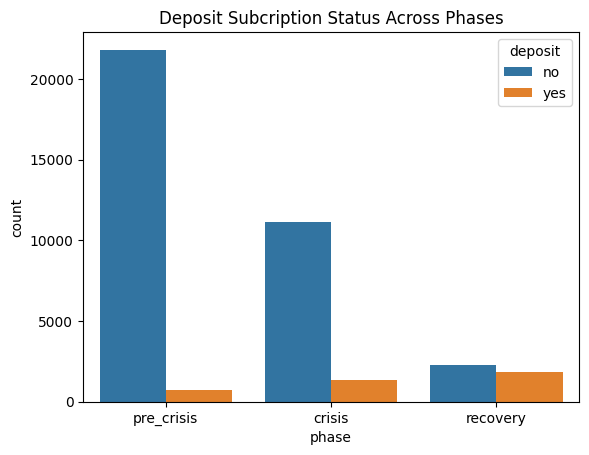

In [62]:
sns.countplot(
    data=df_analysis,
    x='phase',
    hue='deposit'
)

plt.title("Deposit Subcription Status Across Phases")
plt.show()

- Telemarketing outreach was significantly higher during the pre-crisis and crisis periods compared to the recovery phase. However, despite the smaller number of contacts made during the recovery phase, the number of customers who subscribed to term deposits was nearly comparable and proportionally even higher than in the earlier phases.
- This suggests that customers during the recovery period may have been more responsive to deposit offers, potentially reflecting improved financial stability or a stronger preference for secure investment instruments such as term deposits.

#### 2.5.3 Age and Job

In [63]:
df_analysis.groupby('phase')['age'].mean()

,age
phase,
crisis,38.795968
pre_crisis,40.130802
recovery,43.225490


During the recovery phase, the average age of customers who subscribed to term deposits was the highest compared to the crisis and pre-crisis periods. This indicates that older customers were relatively more active in subscribing during the recovery phase.

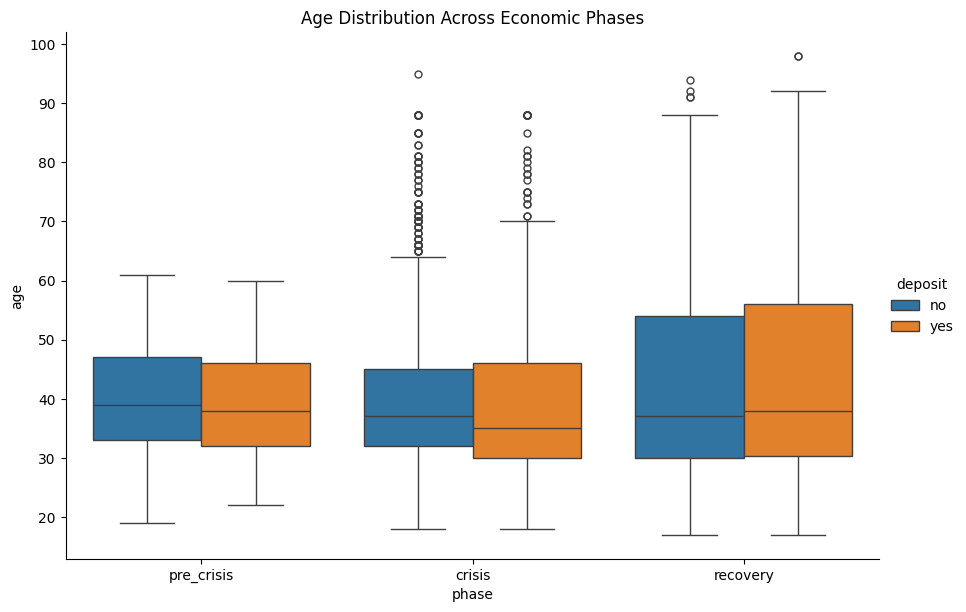

In [64]:
sns.catplot(
    data=df_analysis,
    x='phase',
    y='age',
    hue='deposit',
    kind='box',
    height=6,
    aspect=1.5
)

plt.title("Age Distribution Across Economic Phases")
plt.show()


- The recovery phase also shows the widest age distribution
- The boxplot indicates a larger interquartile range and a broader overall range compared to the pre-crisis and crisis periods
- This suggests that during the recovery phase, customers from a more diverse age group participated in term deposit subscriptions

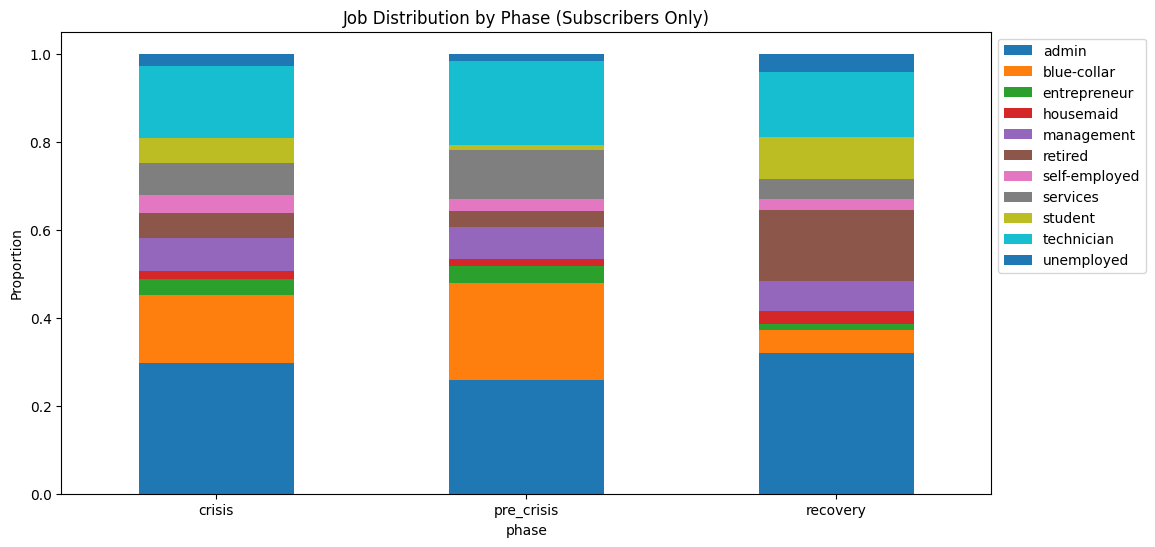

In [65]:
job_phase_yes = pd.crosstab(
    df_analysis[df_analysis['deposit'] == 'yes']['phase'],
    df_analysis[df_analysis['deposit'] == 'yes']['job'],
    normalize='index'
)

job_phase_yes.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title("Job Distribution by Phase (Subscribers Only)")
plt.ylabel("Proportion")
plt.legend(bbox_to_anchor=(1,1))
plt.xticks(rotation=0)
plt.show()


## **!! Notes**

### **subscription rate by phase**

In [66]:
subscription_rate = (
    df_analysis['deposit'].eq('yes').mean()
)

print("Overall Subscription Rate:", round(subscription_rate * 100, 2), "%")

Overall Subscription Rate: 9.89 %


In [67]:
phase_summary = (
    df_analysis
    .groupby('phase')['deposit']
    .agg(
        population='count',
        subscription_rate=lambda x: ((x == 'yes').mean())*100
    )
    .sort_values('subscription_rate', ascending=False)
)

phase_summary['percent_pop']=df_analysis['phase'].value_counts()/len(df_analysis)*100
phase_summary

,population,subscription_rate,percent_pop
phase,,,
recovery,4080,45.147059,10.449749
crisis,12449,10.603261,31.884541
pre_crisis,22515,3.104597,57.665710


### **demographic shift job**

In [68]:
job_summary = (
    df.groupby('job')
    .agg(
        job_count=('job', 'count'),
        subscribers=('deposit', lambda x: (x == 'yes').sum())
    )
)

job_summary['job_percentage'] = job_summary['job_count'] / len(df) * 100
job_summary['subscription_rate'] = job_summary['subscribers'] / job_summary['job_count'] * 100

job_summary = job_summary[['job_count','job_percentage','subscription_rate']].sort_values(by='job_count', ascending=False)

job_summary

,job_count,job_percentage,subscription_rate
job,,,
admin,9852,25.233070,11.682907
blue-collar,8762,22.441348,5.158640
technician,6416,16.432743,9.538653
services,3769,9.653212,6.765720
management,2779,7.117611,9.823678
retired,1632,4.179900,24.264706
entrepreneur,1373,3.516545,7.064822
self-employed,1335,3.419219,8.539326
housemaid,1004,2.571458,9.063745


In [69]:
# total data
total_n = len(df_analysis)

# hitung proporsi tiap job terhadap total populasi
job_population = df_analysis['job'].value_counts(normalize=True)

# ambil job yang populasinya > 5%
selected_jobs = job_population[job_population > 0.05].index

selected_jobs

Index(['admin', 'blue-collar', 'technician', 'services', 'management'], dtype='object', name='job')

In [70]:
df_filtered = df_analysis[df_analysis['job'].isin(selected_jobs)]

In [71]:
job_phase_summary = (
    df_filtered
    .groupby(['phase', 'job'])['deposit']
    .agg(
        population='count',
        subscription_rate=lambda x: ((x == 'yes').mean())*100
    )
    .reset_index()
)
phase_summary['percent_pop']=df_analysis['phase'].value_counts()/len(df_analysis)*100
job_phase_summary

,phase,job,population,subscription_rate
0,crisis,admin,3088,12.629534
1,crisis,blue-collar,2988,6.827309
2,crisis,management,1095,8.949772
3,crisis,services,1321,7.191522
4,crisis,technician,1764,12.188209
5,pre_crisis,admin,5504,3.252180
6,pre_crisis,blue-collar,5528,2.731548
7,pre_crisis,management,1404,3.561254
8,pre_crisis,services,2259,3.408588
9,pre_crisis,technician,4065,3.222632


### **demographic shift by education**

In [72]:
education_summary = (
    df.groupby('education')
    .agg(
        education_count=('education', 'count'),
        subscribers=('deposit', lambda x: (x == 'yes').sum())
    )
)

education_summary['education_percentage'] = education_summary['education_count'] / len(df) * 100
education_summary['subscription_rate'] = education_summary['subscribers'] / education_summary['education_count'] * 100

education_summary = education_summary[['education_count','education_percentage','subscription_rate']].sort_values(by='education_count', ascending=False)

education_summary

,education_count,education_percentage,subscription_rate
education,,,
university degree,11546,29.571765,12.523818
high school,8990,23.025305,9.421580
basic 9 years,5741,14.703924,6.166173
professional course,4987,12.772769,10.066172
basic 4 years,3966,10.157771,9.077156
basic 6 years,2165,5.545026,6.096998
illiterate,17,0.043541,23.529412


In [73]:
# total populasi
total_n = len(df_analysis)

# proporsi tiap education terhadap total populasi
edu_population = df_analysis['education'].value_counts(normalize=True)

# ambil education yang >10%
selected_edu = edu_population[edu_population > 0.10].index

selected_edu

Index(['university degree', 'high school', 'basic 9 years',
       'professional course', 'basic 4 years'],
      dtype='object', name='education')

In [74]:
df_edu_filtered = df_analysis[df_analysis['education'].isin(selected_edu)]

In [75]:
edu_phase_summary = (
    df_edu_filtered
    .groupby(['phase', 'education'])['deposit']
    .agg(
        population='count',
        subscription_rate=lambda x: ((x == 'yes').mean())*100
    )
    .reset_index()
)

edu_phase_summary

,phase,education,population,subscription_rate
0,crisis,basic 4 years,1023,9.481916
1,crisis,basic 9 years,2074,7.232401
2,crisis,high school,3047,9.090909
3,crisis,professional course,1455,11.065292
4,crisis,university degree,3770,13.846154
5,pre_crisis,basic 4 years,2533,2.447690
6,pre_crisis,basic 9 years,3412,2.930832
7,pre_crisis,high school,5050,3.405941
8,pre_crisis,professional course,3005,3.028286
9,pre_crisis,university degree,6163,3.472335


### **average duration**

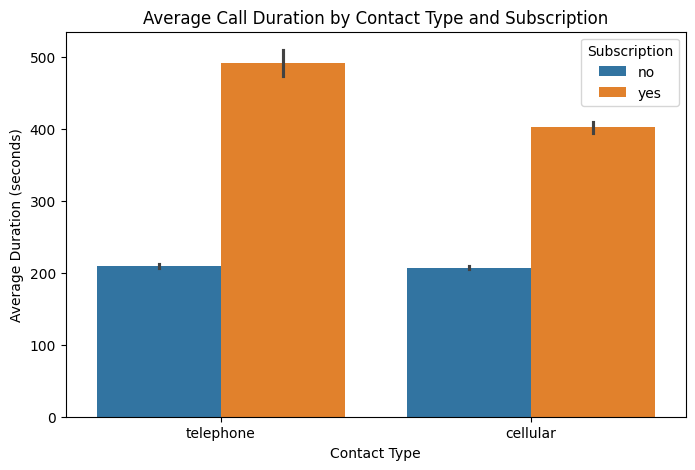

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='contact',
    y='duration',
    hue='deposit',
    estimator='mean'
)

plt.title('Average Call Duration by Contact Type and Subscription')
plt.xlabel('Contact Type')
plt.ylabel('Average Duration (seconds)')
plt.legend(title='Subscription')
plt.show()


In [77]:
df_analysis.pivot_table(
    values='duration',
    index='contact',
    columns='deposit',
    aggfunc='mean'
)

deposit,no,yes
contact,,
cellular,206.973633,402.561218
telephone,209.589135,491.869725


## **3. Inferential Statistics**

### **3.1 Categorical Analysis Using Chi-square**

In [78]:
categorical_features = df[['loan', 'housing', 'day_of_week']].columns

for feature in categorical_features:
    print(f"\n{'='*60}")
    print(f"Feature: {feature}")
    print('='*60)

    # Crosstab
    ct = pd.crosstab(df[feature], df['deposit'], normalize='index') * 100
    print(f"\nSubscription rate by {feature}:")
    print(ct)

    # Chi-square test
    contingency_table = pd.crosstab(df[feature], df['deposit'])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)

    print(f"\nChi-Square Test:")
    print(f"  Chi-square statistic: {chi2:.2f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Degrees of freedom: {dof}")

    if p_value < 0.05:
        print(f"SIGNIFICANT: {feature} is significantly associated with subscription")
    else:
        print(f"NOT SIGNIFICANT: {feature} is not significantly associated")


Feature: loan

Subscription rate by loan:
deposit         no       yes
loan                        
no       90.027030  9.972970
yes      90.530944  9.469056

Chi-Square Test:
  Chi-square statistic: 1.37
  P-value: 0.242333
  Degrees of freedom: 1
NOT SIGNIFICANT: loan is not significantly associated

Feature: housing

Subscription rate by housing:
deposit         no        yes
housing                      
no       90.573864   9.426136
yes      89.702941  10.297059

Chi-Square Test:
  Chi-square statistic: 7.96
  P-value: 0.004784
  Degrees of freedom: 1
SIGNIFICANT: housing is significantly associated with subscription

Feature: day_of_week

Subscription rate by day_of_week:
deposit             no        yes
day_of_week                      
mon          91.340713   8.659287
tue          89.565217  10.434783
wed          89.810979  10.189021
thu          89.385889  10.614111
fri          90.435606   9.564394

Chi-Square Test:
  Chi-square statistic: 22.80
  P-value: 0.000139
  Degr

### **3.2 Numerical Correlation Analysis**

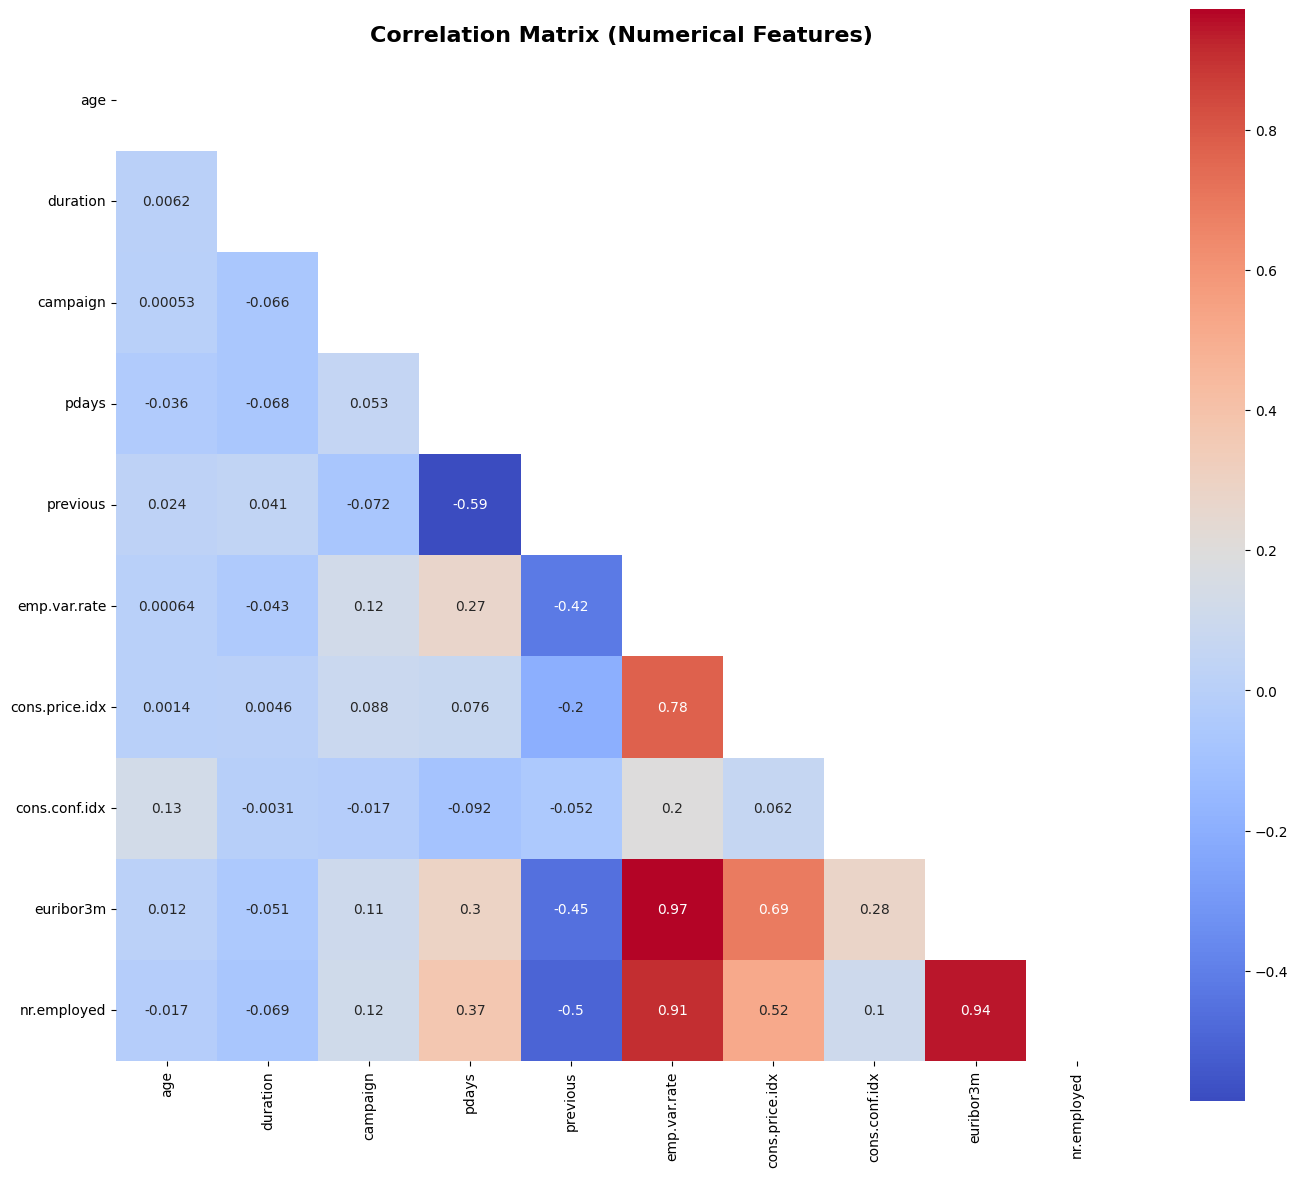

In [79]:
numerical_features = ['age','duration','campaign','pdays','previous','emp.var.rate','cons.price.idx','cons.conf.idx','euribor3m','nr.employed']
df_corr = df.copy()
corr_matrix = df_corr[numerical_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, mask=mask, square=True, cmap='coolwarm')
plt.title('Correlation Matrix (Numerical Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show() #Indexnya diapus

- **Extremely strong correlations**
    - `euribor3m` and `emp.var.rate` (0.97)
    - `nr.employed` and `euribor3m` (0.94)
    - `nr.employed` and `emp.var.rate` (0.91)

- **High positive correlation**: `cons.price.idx` with both `emp.var.rate` (0.77) and `euribor3m` (0.69)

- **Negative correlation**:
    - `pdays` and `previous` (-0.59)
    - `euribor3m`/`emp.var.rate` with `previous` (ranging from -0.42 to -0.5)
    - `campaign` with `age` (0.0001) and `duration` (-0.054)



## **4. Data Prepocessing**

### **4.1 Handling Missing Values, processing columns and Dropping some Socio-economic Features**

In [80]:
df_processed['job'] = df_processed['job'].replace({'admin.': 'admin'})
df_processed['education'] = df_processed['education'].replace({'university.degree': 'university degree'})
df_processed['education'] = df_processed['education'].replace({'professional.course': 'professional course'})
df_processed['education'] = df_processed['education'].replace({'high.school': 'high school'})
df_processed['education'] = df_processed['education'].replace({'basic.9y': 'basic 9 years'})
df_processed['education'] = df_processed['education'].replace({'basic.4y': 'basic 4 years'})
df_processed['education'] = df_processed['education'].replace({'basic.6y': 'basic 6 years'})

In [81]:
df_processed.drop_duplicates(inplace=True)

df_processed = df_processed[(df_processed['campaign'] <= 15) & (df_processed['duration'] <= 1800)]

df_processed['is_default_status_known'] = df['default'].apply(lambda x: 'no' if x == 'unknown' else 'yes')
df_processed.dropna(subset=['housing', 'loan'], inplace=True)
df_processed['was_contacted_before'] = df_processed['pdays'].apply(lambda x: 'no' if x == 999 else 'yes')

# FIX #3: 999 in `pdays` is a sentinel meaning "never contacted before", not a real numeric value.
# Replacing it with NaN (instead of dropping the column outright) lets the numerical pipeline's
# imputer handle it properly, while `was_contacted_before` above still captures the same information
# as a clean binary flag.
df_processed['pdays'] = df_processed['pdays'].replace(999, np.nan)

# NEW FEATURE #16: economic phase (pre-crisis / crisis / recovery), replicating the same
# year-reconstruction + euribor3m-based phase logic used in the EDA (section 2.5), so the
# model can learn from this directly instead of only the raw economic indicator columns.
df_processed['year'] = np.nan

may = df_processed['month'] == 'may'
df_processed.loc[may & df_processed['euribor3m'].between(4, 5), 'year'] = 2008
df_processed.loc[may & df_processed['euribor3m'].between(1.1, 1.4), 'year'] = 2009
df_processed.loc[may & df_processed['euribor3m'].between(0.5, 0.8), 'year'] = 2010

mar = df_processed['month'] == 'mar'
df_processed.loc[mar & df_processed['euribor3m'].between(1.4, 2), 'year'] = 2009
df_processed.loc[mar & ~df_processed['euribor3m'].between(1.4, 2), 'year'] = 2010

apr = df_processed['month'] == 'apr'
df_processed.loc[apr & df_processed['euribor3m'].between(1.3, 1.5), 'year'] = 2009
df_processed.loc[apr & ~df_processed['euribor3m'].between(1.3, 1.5), 'year'] = 2010

jul = df_processed['month'] == 'jul'
df_processed.loc[jul & df_processed['euribor3m'].between(4.8, 5), 'year'] = 2008
df_processed.loc[jul & np.isclose(df_processed['emp.var.rate'], -2.9), 'year'] = 2009
df_processed.loc[jul & np.isclose(df_processed['emp.var.rate'], -1.7), 'year'] = 2010

jun = df_processed['month'] == 'jun'
df_processed.loc[jun & df_processed['euribor3m'].between(4.8, 5), 'year'] = 2008
df_processed.loc[jun & df_processed['euribor3m'].between(1, 1.3), 'year'] = 2009
df_processed.loc[jun & df_processed['euribor3m'].between(0.7, 0.8), 'year'] = 2010

aug = df_processed['month'] == 'aug'
df_processed.loc[aug & df_processed['euribor3m'].between(4.8, 5), 'year'] = 2008
df_processed.loc[aug & np.isclose(df_processed['emp.var.rate'], -2.9), 'year'] = 2009
df_processed.loc[aug & np.isclose(df_processed['emp.var.rate'], -1.7), 'year'] = 2010

sep = df_processed['month'] == 'sep'
df_processed.loc[sep & df_processed['euribor3m'].between(0.7, 0.82), 'year'] = 2009
df_processed.loc[sep & ~df_processed['euribor3m'].between(0.7, 0.82), 'year'] = 2010

oct_ = df_processed['month'] == 'oct'
df_processed.loc[oct_ & df_processed['euribor3m'].between(4.7, 5.1), 'year'] = 2008
df_processed.loc[oct_ & df_processed['euribor3m'].between(0.7, 0.8), 'year'] = 2009
df_processed.loc[oct_ & df_processed['euribor3m'].between(0.9, 1.1), 'year'] = 2010

nov = df_processed['month'] == 'nov'
df_processed.loc[nov & df_processed['euribor3m'].between(3, 5), 'year'] = 2008
df_processed.loc[nov & np.isclose(df_processed['emp.var.rate'], -3.4), 'year'] = 2009
df_processed.loc[nov & np.isclose(df_processed['emp.var.rate'], -1.1), 'year'] = 2010

dec = df_processed['month'] == 'dec'
df_processed.loc[dec & df_processed['euribor3m'].between(3, 4), 'year'] = 2008
df_processed.loc[dec & ~df_processed['euribor3m'].between(3, 4), 'year'] = 2009

df_processed['year'] = df_processed['year'].astype('Int64')
df_processed['date'] = pd.to_datetime(
    df_processed['year'].astype(str) + '-' + df_processed['month'].astype(str),
    format='%Y-%b'
)

df_processed['phase'] = 'recovery'
df_processed.loc[df_processed['euribor3m'] >= 4.5, 'phase'] = 'pre_crisis'
df_processed.loc[
    (df_processed['euribor3m'].between(1.070, 4.5)) &
    (df_processed['date'] < '2009-08-01'),
    'phase'
] = 'crisis'

# `year` and `date` were only needed to derive `phase`; drop them so they don't leak
# directly into the model (they're really just an artifact of the euribor3m reconstruction).
df_processed.drop(['year', 'date'], axis=1, inplace=True)

df_processed.drop(['default','duration','emp.var.rate','cons.price.idx'], axis=1, inplace=True)

In [82]:
df_processed.head()

,age,job,marital,education,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,cons.conf.idx,euribor3m,nr.employed,deposit,is_default_status_known,was_contacted_before,phase
0,56,housemaid,married,basic 4 years,no,no,telephone,may,mon,1,NaN,0,nonexistent,-36.4,4.857,5191.0,no,yes,no,pre_crisis
1,57,services,married,high school,no,no,telephone,may,mon,1,NaN,0,nonexistent,-36.4,4.857,5191.0,no,yes,no,pre_crisis
2,37,services,married,high school,yes,no,telephone,may,mon,1,NaN,0,nonexistent,-36.4,4.857,5191.0,no,yes,no,pre_crisis
3,40,admin,married,basic 6 years,no,no,telephone,may,mon,1,NaN,0,nonexistent,-36.4,4.857,5191.0,no,yes,no,pre_crisis
4,56,services,married,high school,no,yes,telephone,may,mon,1,NaN,0,nonexistent,-36.4,4.857,5191.0,no,yes,no,pre_crisis


## **5. Machine Learning**

The models that are utilized in this machine learning includes:

0. Logistic Regression
1. KNN
2. Decision Tree
3. Random Forest
4. LightGBM
5. XGBoost

### **5.1 Define X (Target) and y (Features)**

In [83]:
deposit = df_processed['deposit'].map({'no': 0, 'yes': 1})
X = df_processed.drop('deposit', axis=1)

<u> Splitting categorical features and numerical features

In [84]:
ordinal_features = ['month', 'day_of_week', 'education']
target_features = ['job']

all_categorical = X.select_dtypes(include=['object']).columns.tolist()
categorical_features = [c for c in all_categorical if c not in ordinal_features + target_features]
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()

month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']
education_order = ['illiterate', 'basic 4 years', 'basic 6 years', 'basic 9 years',
                    'high school', 'professional course', 'university degree']
ordinal_category_orders = [month_order, day_order, education_order]

### **5.2 Train-Test Split**

In [85]:
X_train, X_test, deposit_train, deposit_test = train_test_split(X, deposit, test_size=0.2, random_state=42, stratify=deposit)

### **5.3 Feature Engineering**

In [86]:
numerical_pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('imputer', SimpleImputer(strategy='median'))])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))])

ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordinal_category_orders,
                               handle_unknown='use_encoded_value', unknown_value=-1))])

target_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(random_state=42))])

preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('target', target_pipeline, target_features)])

### **5.4 Model Benchmarking (Baseline Approach)**

In [87]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
}
recall_scorer = make_scorer(recall_score)
scoring = {
    'recall': recall_scorer,
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
    }
results = []

for model_name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_validate(pipe,
                            X_train,
                            deposit_train,
                            cv=cv_strategy,
                            scoring=scoring,
                            return_train_score=True,
                            n_jobs=-1)
    results.append({
        'model': model_name,
        'recall': scores['test_recall'].mean(),
        'recall_std': scores['test_recall'].std(),
        'roc_auc': scores['test_roc_auc'].mean(),
        'pr_auc': scores['test_pr_auc'].mean(),
        'fit_time': scores['fit_time'].mean(),
        'score_time': scores['score_time'].mean()
    })

In [88]:
benchmark_df = pd.DataFrame(results)
benchmark_df = benchmark_df.sort_values(by='recall', ascending=False).reset_index(drop=True)
benchmark_df

,model,recall,recall_std,roc_auc,pr_auc,fit_time,score_time
0,Decision Tree,0.337715,0.015120,0.619390,0.176650,0.503382,0.114667
1,XGBoost,0.280635,0.008693,0.784206,0.427914,0.950696,0.189561
2,Random Forest,0.271967,0.017834,0.772789,0.417983,5.529613,0.514918
3,LightGBM,0.269448,0.010766,0.797813,0.466194,0.763130,0.208384
4,KNN,0.260496,0.011208,0.721420,0.312761,0.425914,3.653874
5,Logistic Regression,0.206493,0.013047,0.777537,0.431764,0.588302,0.145226


<u> Visualizing benchmark df

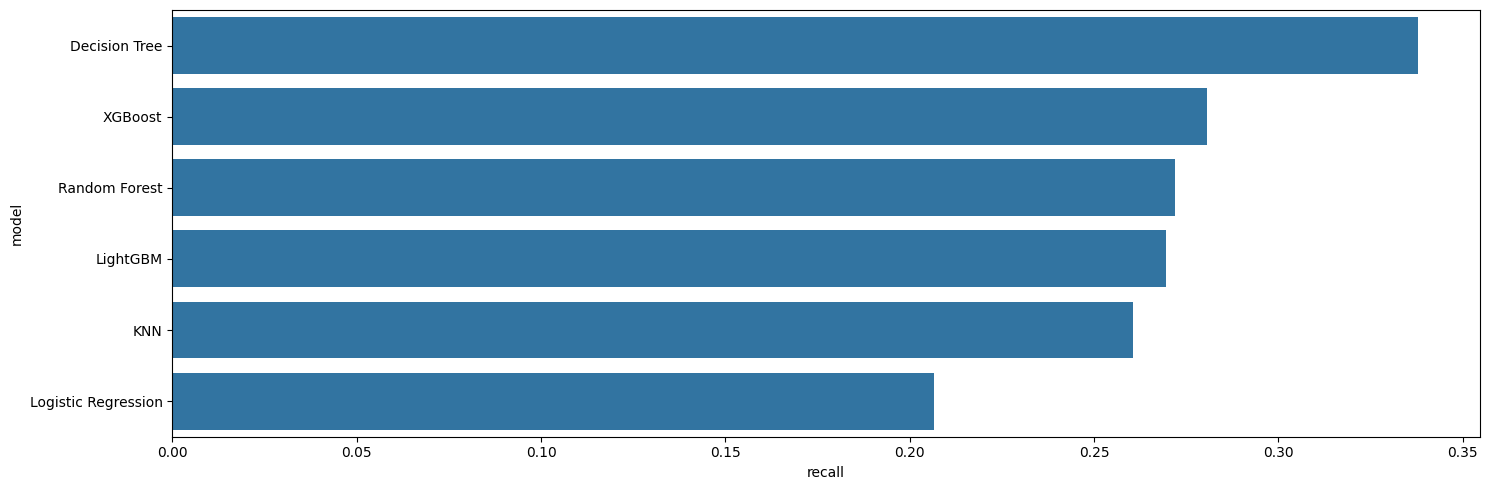

In [89]:
fig, ax = plt.subplots(1, figsize=(15, 5))
sns.barplot(data=benchmark_df, y='model', x='recall')
plt.tight_layout()
plt.show()

### **5.5 Baseline and Balanced Model**

In [90]:
models_with_class_weight = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Logistic Regression Balanced': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Decision Tree Balanced': DecisionTreeClassifier(random_state=42,class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Random Forest Balanced': RandomForestClassifier(random_state=42, n_estimators=100,class_weight='balanced'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    'LightGBM Balanced': LGBMClassifier(random_state=42, verbose=-1,class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'XGBoost Balanced': XGBClassifier(random_state=42, eval_metric='logloss',class_weight='balanced')
}

results_balanced = []
for model_name, model in models_with_class_weight.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = cross_validate(pipe,
                            X_train,
                            deposit_train,
                            cv=cv_strategy,
                            scoring=scoring,
                            return_train_score=True,
                            n_jobs=-1)
    results_balanced.append({
        'model': model_name,
        'recall': scores['test_recall'].mean(),
        'recall_std': scores['test_recall'].std(),
        'roc_auc': scores['test_roc_auc'].mean(),
        'pr_auc': scores['test_pr_auc'].mean(),
        'fit_time': scores['fit_time'].mean(),
        'score_time': scores['score_time'].mean()
    })

In [91]:
balanced_df = pd.DataFrame(results_balanced)
balanced_df = balanced_df.sort_values(by='recall', ascending=False).reset_index(drop=True)
balanced_df

,model,recall,recall_std,roc_auc,pr_auc,fit_time,score_time
0,Logistic Regression Balanced,0.664523,0.019146,0.779756,0.427206,0.643878,0.106116
1,LightGBM Balanced,0.628151,0.014498,0.797714,0.465314,0.965198,0.229528
2,Decision Tree,0.337715,0.015120,0.619390,0.176650,0.464001,0.105131
3,Decision Tree Balanced,0.314773,0.014255,0.612968,0.175068,0.556489,0.141687
4,XGBoost,0.280635,0.008693,0.784206,0.427914,0.714933,0.156553
5,XGBoost Balanced,0.280635,0.008693,0.784206,0.427914,0.925085,0.252654
6,Random Forest,0.271967,0.017834,0.772789,0.417983,4.124853,0.407083
7,LightGBM,0.269448,0.010766,0.797813,0.466194,0.786815,0.218062
8,KNN,0.260496,0.011208,0.721420,0.312761,0.309546,3.877108
9,Random Forest Balanced,0.259377,0.017474,0.769438,0.414188,4.280082,0.400711


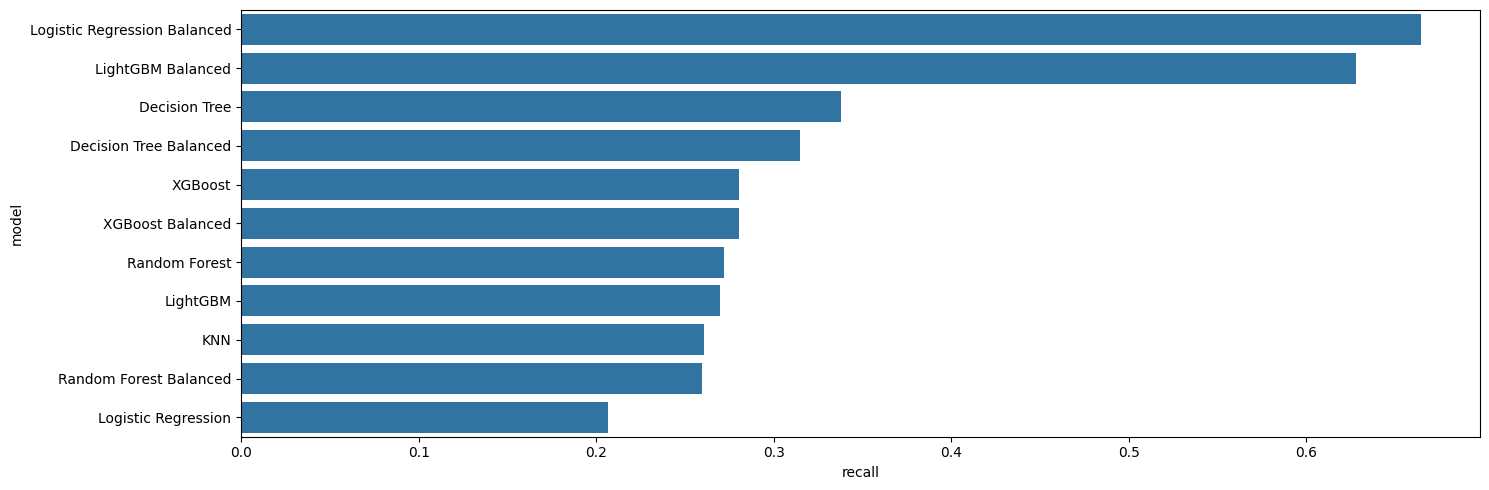

In [92]:
fig, ax = plt.subplots(1, figsize=(15, 5))
sns.barplot(data=balanced_df, y='model', x='recall')
plt.tight_layout()
plt.show()

In [93]:
base_model = LGBMClassifier(verbose=-1, class_weight='balanced')

- Even though the "recall" score is higher in Logistic Regression, the score gap to LightGBM is small.

- LightGBM model has smaller standard deviation (0.0145), meaning it is more consistent across folds and more trustworthy.

- LightGBM has better overall discriminative power (ROC-AUC) than Logistic Regression.

- LightGBM model is based on gradient boosting decision trees but it is:

  - Faster

  - High prediction accuracy

  - More memory-efficient

  - Scalable to very large datasets

  - Can deal with imbalanced datasets

compared with traditional gradient boosting methods.

### **5.7 Hyperparameter Tuning**

In [94]:
lgbm_hyperparam = {
    'classifier__n_estimators': [100, 200, 300, 400],
    'classifier__max_depth': [3, 4, 5, 6, 7],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__class_weight': ['balanced']
}
tuned_results = []

tuning_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', base_model)
])

recall_scorer = make_scorer(recall_score)
grid_search = GridSearchCV(
    tuning_pipeline,
    lgbm_hyperparam,
    scoring=recall_scorer,
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)
tuning_start = time.time()
grid_search.fit(X_train, deposit_train)
tuning_total_time = time.time() - tuning_start

best_fit_time = grid_search.cv_results_['mean_fit_time'][grid_search.best_index_]
best_score_time = grid_search.cv_results_['mean_score_time'][grid_search.best_index_]
best_recall_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
best_model.fit(X_train, deposit_train)

deposit_pred = best_model.predict(X_test)
deposit_pred_proba = best_model.predict_proba(X_test)[:, 1]

recall = recall_score(deposit_test, deposit_pred)
roc_auc = roc_auc_score(deposit_test, deposit_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(deposit_test, deposit_pred_proba)
pr_auc = auc(recall_curve, precision_curve)

print(f"Recall: {recall:.4f}  (+/- {best_recall_std:.4f} across CV folds)")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Best model fit time (per fold): {best_fit_time:.3f} sec")
print(f"Total GridSearchCV time ({len(grid_search.cv_results_['params'])} combinations): {tuning_total_time/60:.1f} min")

tuned_results.append({
    'model': 'Tuned Model',
    'recall': recall,
    'recall_std': best_recall_std,
    'roc_auc': roc_auc,
    'pr_auc': pr_auc,
    'fit_time': best_fit_time,
    'score_time': best_score_time
})
print(f"Best Hyperparameters: {best_params}")

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Recall: 0.6655  (+/- 0.0176 across CV folds)
ROC-AUC: 0.8145
PR-AUC: 0.4858
Best model fit time (per fold): 1.072 sec
Total GridSearchCV time (80 combinations): 6.0 min
Best Hyperparameters: {'classifier__class_weight': 'balanced', 'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__n_estimators': 100}


In [95]:
tuned_df = pd.DataFrame(tuned_results)
tuned_df = tuned_df.sort_values(by='recall', ascending=False).reset_index(drop=True)  # FIX #1
tuned_df

,model,recall,recall_std,roc_auc,pr_auc,fit_time,score_time
0,Tuned Model,0.665548,0.01759,0.814528,0.485761,1.07213,0.117994


### **5.8 Model Evaluation**

In [96]:
lgbm_balanced = balanced_df[balanced_df['model'] == 'LightGBM Balanced'].copy()
lgbm_balanced['Stage'] = 'LightGBM Balanced'

lgbm_tuned = tuned_df.copy()
lgbm_tuned['Stage'] = 'Tuned LightGBM'

df_lgbm_compare = pd.concat([lgbm_balanced, lgbm_tuned], ignore_index=True)

stage_order = ['LightGBM Balanced', 'Tuned LightGBM']
df_lgbm_compare['Stage'] = pd.Categorical(df_lgbm_compare['Stage'], categories=stage_order, ordered=True)
df_lgbm_compare = df_lgbm_compare.sort_values('Stage').reset_index(drop=True)

df_lgbm_compare.style.highlight_max(color='lightgreen', axis=0) \
                      .highlight_min(color='#ffcccc', axis=0)

,model,recall,recall_std,roc_auc,pr_auc,fit_time,score_time,Stage
0,LightGBM Balanced,0.628151,0.014498,0.797714,0.465314,0.965198,0.229528,LightGBM Balanced
1,Tuned Model,0.665548,0.017590,0.814528,0.485761,1.072130,0.117994,Tuned LightGBM


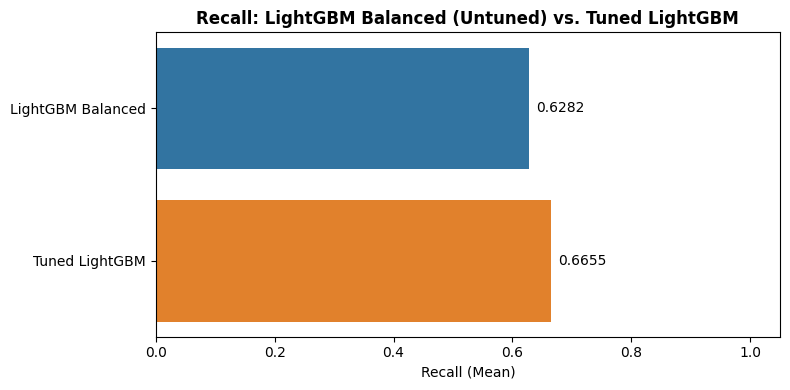

In [97]:
fig, ax = plt.subplots(figsize=(8, 4))

sns.barplot(data=df_lgbm_compare, y='Stage', x='recall',
            palette={'LightGBM Balanced': '#1F77B4',
                     'Tuned LightGBM':    '#FF7F0E'},
            ax=ax)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.4f}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontsize=10)

ax.set_title('Recall: LightGBM Balanced (Untuned) vs. Tuned LightGBM', fontweight='bold')
ax.set_xlabel('Recall (Mean)')
ax.set_ylabel('')
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

Why tuned? we prioritize recall, and based on the two different model, tuned model has the highest recall compared to others.

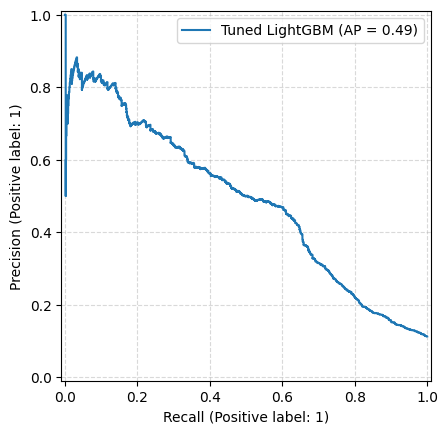

In [98]:
from sklearn.metrics import PrecisionRecallDisplay
display = PrecisionRecallDisplay.from_estimator(
    best_model,
    X_test,
    deposit_test,
    name="Tuned LightGBM")
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.48)
plt.show()

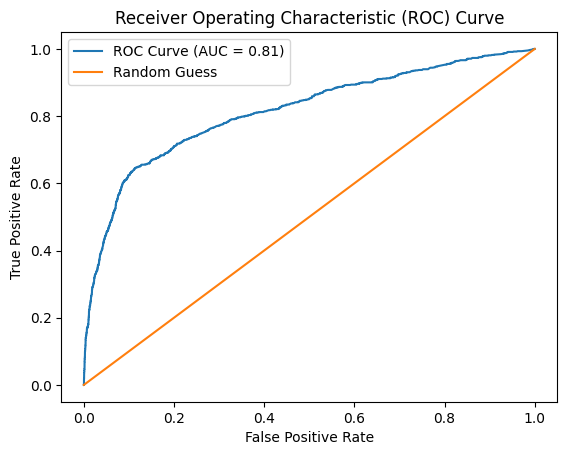

In [99]:
fpr, tpr, thresholds = roc_curve(deposit_test, deposit_pred_proba)
roc_auc_value = roc_auc_score(deposit_test, deposit_pred_proba)

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc_value:.2f})')
plt.plot([0, 1], [0, 1], label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

ROC-AUC approximately 0.81 meaning the model act as good classifier (>0.8) and also indicate that model is not leaking (0.99 - 1.00)

### **5.9 Cost Benefit Analysis and Shap interpretable Model**

**1. Telecommunication cost** (Portugal, 2008–2013, conservative upper-bound):
- Landline: EUR 0.03/min
- Cellular: EUR 0.25/min

**2. Human labor cost:**
- Portugal minimum wage 2008–2010: EUR 497–554/month
- Per minute: EUR 0.10/min
- With ×2 overhead (office space, management, software, taxes): **EUR 0.20/min**

**Total call rate (cellular + labor):** EUR 0.45/min

**Average call duration by outcome** (from dataset, cellular contacts):
- Failed call (no subscription): 218.5 seconds = 3.64 min
- Successful call (subscribed): 501.6 seconds = 8.36 min

**Derived cost per call:**

- Failed call:    3.64 × EUR 0.45 = **EUR 1.639**
- Successful call: 8.36 × EUR 0.45 = **EUR 3.762**

All calculations below use the **cellular rate** (conservative upper-bound).

---

**Value per Subscription**

On average, Portuguese customers deposit EUR 5,000 in a term deposit.
Bank profit margin: 1–2% → **EUR 50 per successful subscription** (conservative, 1%).

---

**Sample Size (Test Set)**

Base rate = actual yes / total customers = 894 / 7,948 = 11.25%

| | Count |
|---|:---:|
| Total customers | 7,948 |
| Actual non-subscribers (No) | 7,054 |
| Actual subscribers (Yes) | 894 |
| Overall conversion rate | 11.25% |


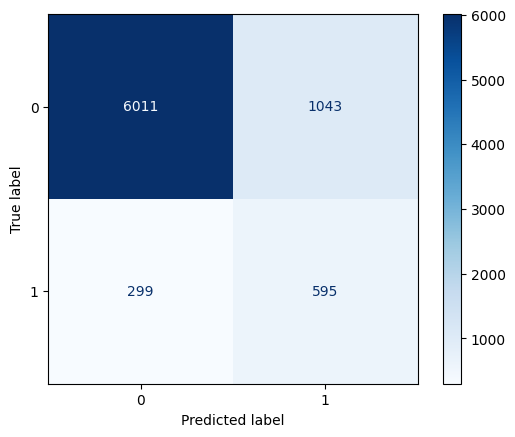

In [100]:
deposit_pred = best_model.predict(X_test)
cm = confusion_matrix(deposit_test, deposit_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.show()

The model flags **1,638 customers** to call (TP + FP = 595 + 1,043).


### Question: "If we have a budget of 1,638 calls — should we spend it calling random customers or model-flagged customers?"

**Scenario A — Random 1,638 Calls (No Model)**

Without a model, the bank dials 1,638 customers at random.
At an 11.25% base conversion rate, expected outcomes:

Expected subscribers = 1,638 × 11.25%            =  184 customers

Expected non-subscribers = 1,638 − 184            = 1,454 customers

Revenue  = 184 × EUR 50                           = EUR  9,212.20

Cost     = 1,454 × EUR 1.639 + 184 × EUR 3.762   = EUR  3,075.12

---

Net Profit = EUR  6,137.08

Total time = 1,454 × 218.5 + 184 × 501.6         = 410,016 sec
≈ 113.9 hours

Profit/hour = EUR 6,137.08 / 113.9                = EUR 53.88/hr

**Scenario B — After ML: Model-Flagged 1,638 Calls**

The model selectively flags 1,638 customers most likely to subscribe.

After ML conversion rate: 595 TP ÷ (595 TP + 1,043 FP) = 595 ÷ 1,638 = 36.32%

At 36.32% precision, actual outcomes from the confusion matrix:

Actual subscribers reached (TP)  = 595 customers

Actual non-subscribers called (FP) = 1,043 customers

Revenue  = 595 × EUR 50                           = EUR 29,750.00

Cost     = 1,043 × EUR 1.639 + 595 × EUR 3.762   = EUR  3,947.36

---

Net Profit = EUR 25,802.64

Total time = 595 × 501.6 + 1,043 × 218.5         = 526,314 sec
≈ 146.2 hours

Profit/hour = EUR 25,802.64 / 146.2               = EUR 176.49/hr

**Comparison — Same 1,638 Calls, Different Targeting**

| | Random Calls | After ML | Difference |
|---|:---:|:---:|:---:|
| Calls made | 1,638 | 1,638 | — |
| Conversion rate | 11.25% | 36.32% | +25.07pp |
| Subscribers reached | 184 | 595 | **+411** |
| Wasted calls | 1,454 | 1,043 | −411 |
| Revenue (EUR) | 9,212.20 | 29,750.00 | +EUR 20,537.80 |
| Operating cost (EUR) | 3,075.12 | 3,947.36 | +EUR 872.24 |
| **Net profit (EUR)** | **6,137.08** | **25,802.64** | **+EUR 19,665.56** |
| Calling time (hours) | 113.9 | 146.2 | +32.3 hrs |
| **Profit/hour (EUR)** | **53.88** | **176.49** | **+EUR 122.61** |

---

## Key Takeaways

- Profit increase  = (25,802.64 − 6,137.08) / 6,137.08 × 100 = +320.4%

- Profit multiplier = 25,802.64 / 6,137.08                    = 4.20x

- Generates **EUR 19,666 more profit**, reaches **411 more subscribers**, and delivers **4.20x the return** compared to random calling.

**Shap Interpretable Model**

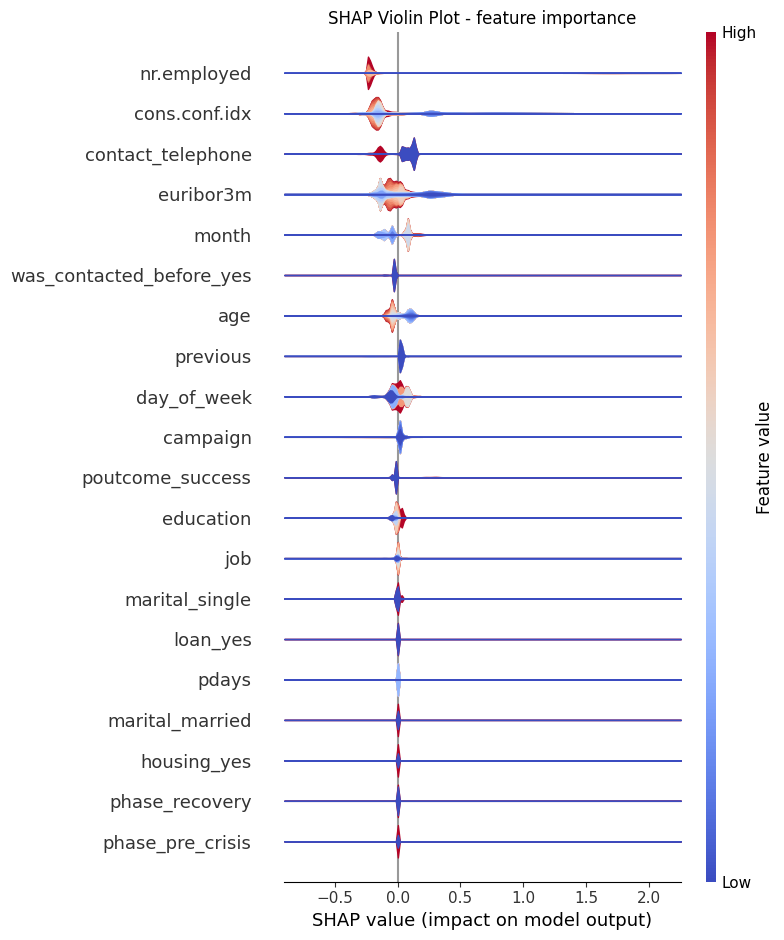

In [101]:
X_train_preprocessed = best_model.named_steps['preprocessor'].transform(X_train)
explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
shap_values = explainer.shap_values(X_train_preprocessed[:1000])
feature_names_encoded = (
    numerical_features +
    list(best_model.named_steps['preprocessor']
         .named_transformers_['cat']
         .named_steps['encoder']
         .get_feature_names_out(categorical_features)) +
    ordinal_features +
    target_features
)

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train_preprocessed[:1000],
                 feature_names=feature_names_encoded, show=False,
                 plot_type="layered_violin", color="coolwarm",)
plt.title('SHAP Violin Plot - feature importance')
plt.tight_layout()
plt.show()

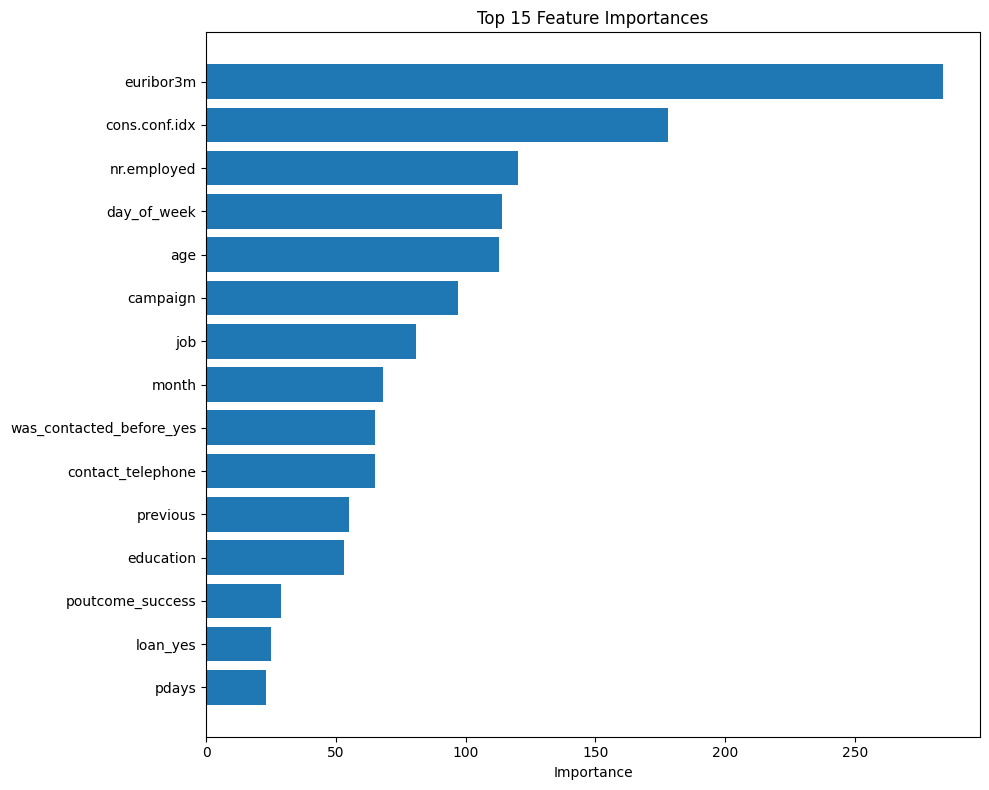

In [102]:
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    feature_importance = best_model.named_steps['classifier'].feature_importances_


    importance_df = pd.DataFrame({
        'Feature': feature_names_encoded,
        'Importance': feature_importance
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(10, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## **6.  Conclusion and Recommendation**

**Conclusion**

1. **Data Key Findings:**
   * Customers who have these characteristics are likely to subscribe to term deposits:
      1. Age – Late 20s to early 30s
      2. Marital status – Single
      3. Job – Student and Retired
      4. Education – University degree
   * `duration`, `euribor3m`, `emp.var.rate`, `cons.price.idx`, and `nr.employed` have high discriminative power in the EDA, meaning these features can distinguish subscribers from non-subscribers. Note: `duration`, `emp.var.rate`, and `cons.price.idx` were excluded from the final model (the first due to data leakage, the others due to multicollinearity), so only `euribor3m`, `cons.conf.idx`, and `nr.employed` carry this signal in the deployed model — confirmed by SHAP as the top economic drivers.
   * Customers are more likely to subscribe when contacted recently, and specifically in the months of March and December.
   * Longer call duration is associated with a higher chance of deposit subscription — engaged conversations (explaining terms, answering questions) precede conversions, while quick "no thanks" calls end in rejection. Note: because duration is only known *after* a call happens, it's a strong EDA signal but cannot be used as a predictive feature.
   * The majority of customers who subscribed in a previous campaign have a higher chance of subscribing again in the next campaign.
   * Subscriptions are more frequent when economic conditions are weaker: lower `employment variation rate`, lower `number of employees` (`nr.employed`), and **lower** interest rates (`euribor3m`) all coincide with higher subscription rates — consistent with customers seeking deposit safety during uncertain economic periods rather than during growth periods.

2. **Model Performance:**
   * Achieved Recall: 0.6655 (Target: ≥0.60) ✅ Met
   * Achieved ROC-AUC: 0.81 (Target: ≥0.80) ✅ Met
   * Achieved PR-AUC: 0.49 (Target: ≥0.50) ⚠️ Not met (0.012 short)

3. **Model Key Findings:**
   * Successfully built a predictive model optimised to **minimise missed subscribers (FN)**, correctly identifying ~66.5% of actual subscribers (Recall), reducing missed subscribers from 654 (untuned baseline) to 299 after tuning — a 54.3% reduction in FN
   * Addressed class imbalance through resampling and class weighting
   * Identified the most influential features for subscription prediction (led by `nr.employed`, `euribor3m`, and contact channel), validated independently by SHAP analysis
   * The tuned model generates **EUR 14,931 more net profit** than the untuned baseline (+137%), demonstrating that recall-focused tuning meaningfully improves business outcomes beyond just the metric score

4. **Business Impact:**
   * Targeting only model-flagged customers instead of calling everyone reduces total profit by ~13.3% (EUR 29,775.27 → EUR 25,802.13) but cuts calling time by ~73.5% (552.6 → 146.2 hours) — meaning **profit-per-hour rises 3.28x (228% higher)**. If that freed-up calling time is redirected toward reaching more flagged prospects, the model enables substantially higher total profit than blanket calling for the same time investment.
   * Every 100 model-flagged calls generates **EUR 1,575.22 in profit** vs. EUR 374.63 per 100 random calls — a **4.2x improvement in call efficiency**
   * Reduces unnecessary customer contacts by 6,011 per campaign cycle, improving customer satisfaction and reducing operational costs by EUR 10,976.87
   * Provides data-driven prioritization for call center operations

**Recommendation**

1. **Recommendations for Data:**
   * Feature enrichment: Add more informative features such as location-based features
   * Behavioral data: Integrate transaction history or average monthly balances to better predict the liquidity of a customer before outreach

2. **Recommendations for Business (Marketing Team):**
   * **Dynamic targeting strategy:**
      1. Prioritize outreach to high-probability customers identified by the model, especially during periods of low `euribor3m` rates or low consumer confidence, where traditional mass marketing is least efficient
      2. Instead of calling all customers (baseline), the bank should only contact those flagged by the model. This allows the bank to achieve higher conversion rates with significantly fewer calls — reducing operating costs by EUR 10,976.87 per campaign while simultaneously increasing profit-per-hour by 228%
      3. Create "Gold," "Silver," and "Bronze" lead tiers based on model probability, assigning the most experienced sales agents to the "Gold" tier to further boost conversion rates
   * **Economic phase adaptation:** Develop specific scripts for different economic phases — for instance, emphasizing safety and stability during periods of low consumer confidence and low interest rates, when customers are demonstrably more receptive, consistent with the `phase` feature introduced in the model
   * In the case where budget is constrained (e.g. funding only reaches 1,000 customers), the marketing team can rank the top 1,000 highest-scoring customers by subscription probability. If customers have the same overall prediction percentage, rank by their highest-contributing top features (per SHAP) as a tiebreaker.

3. **Recommendations for Model:**
   * **Threshold tuning:** The current model uses the default 0.5 classification threshold. Given the aim is to minimise FN, lowering the threshold (e.g. to 0.3–0.4) will increase recall further at the cost of more wasted calls — run the threshold sensitivity table to find the optimal cut-off for the bank's available call-center capacity
   * **Periodic re-training:** Retrain the model every 3–6 months to account for shifting consumer behavior as macroeconomic indicators fluctuate, since `nr.employed` and `euribor3m` — the top two drivers — are inherently time-varying
   * **PR-AUC improvement:** The PR-AUC target of ≥0.50 was narrowly missed (0.4882). Future iterations could explore additional feature engineering, ensemble stacking, or cost-sensitive learning directly targeting PR-AUC to close this gap

In [104]:
# save model
# joblib.dump(best_model, 'finalised_model.sav')

['finalised_model.sav']